In [1]:
# sort q profiles with respect to w500 and plot, and sort w profiles with respect to q750.

# Load Data

In [2]:
import xarray as xr
import numpy as np
import intake
cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")["online"]

In [3]:
#In order to open a dataset from the catalog below, use the catalog as follows:
ds = cat["ERA5"](zoom=7).to_dask()

In [4]:
ds.time

<xarray.DataArray 'time' (time: 1008)> Size: 8kB
array(['1940-01-01T00:00:00.000000000', '1940-02-01T00:00:00.000000000',
       '1940-03-01T00:00:00.000000000', ..., '2023-10-01T00:00:00.000000000',
       '2023-11-01T00:00:00.000000000', '2023-12-01T00:00:00.000000000'],
      shape=(1008,), dtype='datetime64[ns]')
Coordinates:
    crs      float32 4B ...
  * time     (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2023-12-01
Attributes:
    axis:     T

In [4]:
q=ds.q
w=ds.w

In [5]:
print(q)
print(w)

<xarray.DataArray 'q' (time: 1008, level: 37, cell: 196608)> Size: 29GB
dask.array<open_dataset-q, shape=(1008, 37, 196608), dtype=float32, chunksize=(24, 4, 4096), chunktype=numpy.ndarray>
Coordinates:
  * cell     (cell) float32 786kB 0.0 1.0 2.0 ... 1.966e+05 1.966e+05 1.966e+05
    crs      float32 4B ...
    lat      (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
  * level    (level) float32 148B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
    lon      (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
  * time     (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2023-12-01
Attributes:
    grid_mapping:   crs
    levtype:        isobaricInhPa
    long_name:      Specific humidity
    standard_name:  specific_humidity
    units:          kg kg**-1
<xarray.DataArray 'w' (time: 1008, level: 37, cell: 196608)> Size: 29GB
dask.array<open_dataset-w, shape=(1008, 37, 196608), dtype=float32, chunksize=(24, 4, 4096), chunktype=numpy.ndarray>
Coo

# Example year of 2020

In [6]:
def _format_level(base_level) -> str:
    """Return a compact string for scalar or list of levels."""
    levels = np.atleast_1d(base_level)
    if len(levels) == 1:
        return f"{int(levels[0])}"
    else:
        return f"{int(levels.min())}–{int(levels.max())}"  # e.g. "800–1000"

def sort_profiles_by_level(
    da_base: xr.DataArray,
    da_target: xr.DataArray,
    base_level,
    percentiles=None,
    time_slice=None,
    season: str | None = None,
    lat_bounds: tuple | None = None,   # e.g. (-30, 30) for tropics
    output_file: str | None = None,
) -> xr.DataArray:
    import os

    # ── early exit if file already exists ─────────────────────────────────────
    if output_file is not None and os.path.exists(output_file):
        print(f"File exists, loading: {output_file}")
        return xr.open_dataarray(output_file)

    if percentiles is None:
        percentiles = np.arange(0, 101, 1)

    # ── time selection ────────────────────────────────────────────────────────
    # if time_slice is not None:
    #     da_base   = da_base.sel(time=time_slice)
    #     da_target = da_target.sel(time=time_slice)
    # ── time selection ────────────────────────────────────────────────────────
    if time_slice is not None:
        if isinstance(time_slice, slice):
            da_base   = da_base.sel(time=time_slice)
            da_target = da_target.sel(time=time_slice)
        else:
            # assume boolean array/DataArray indexer (e.g. El Niño mask)
            time_slice = np.asarray(time_slice)   # ensure numpy, not dask
            da_base   = da_base.isel(time=time_slice)
            da_target = da_target.isel(time=time_slice)

    if season is not None:
        season_months = {
            "DJF": [12, 1, 2], "MAM": [3, 4, 5],
            "JJA": [6, 7, 8],  "SON": [9, 10, 11],
        }
        months = season_months[season.upper()]
        mask = da_base.time.dt.month.isin(months)
        da_base   = da_base.isel(time=mask)
        da_target = da_target.isel(time=mask)

    # ── spatial crop by latitude ──────────────────────────────────────────────
    if lat_bounds is not None:
        lat_min, lat_max = lat_bounds
        lat = da_base.lat.compute()           # force lat to numpy
        cell_mask = ((lat >= lat_min) & (lat <= lat_max)).compute()  # force mask to numpy
        da_base   = da_base.isel(cell=cell_mask)
        da_target = da_target.isel(cell=cell_mask)
        print(f"  Cropped to lat [{lat_min}, {lat_max}]: "
              f"{int(cell_mask.sum())} / {len(cell_mask)} cells retained")

    # ── extract / average the sorting key at base_level ──────────────────────
    levels = np.atleast_1d(base_level)
    if len(levels) == 1:
        key = da_base.sel(level=levels[0], method="nearest")
    else:
        key = da_base.sel(level=levels).mean("level")

    # ── compute sorted profiles time-step by time-step ───────────────────────
    n_time   = da_target.sizes["time"]
    n_levels = da_target.sizes["level"]
    n_pct    = len(percentiles)

    result = np.full((n_time, n_levels, n_pct), np.nan, dtype=np.float32)

    for t in range(n_time):
        key_t    = key.isel(time=t).values
        target_t = da_target.isel(time=t).values

        bin_edges = np.nanpercentile(key_t, percentiles)

        for p_idx in range(n_pct - 1):
            lo, hi = bin_edges[p_idx], bin_edges[p_idx + 1]
            mask = (key_t >= lo) & (key_t < hi)
            if mask.sum() > 0:
                result[t, :, p_idx] = target_t[:, mask].mean(axis=-1)

        mask = key_t >= bin_edges[-1]
        if mask.sum() > 0:
            result[t, :, -1] = target_t[:, mask].mean(axis=-1)

    # ── wrap in DataArray ─────────────────────────────────────────────────────
    out = xr.DataArray(
        result,
        dims=["time", "level", "percentile"],
        coords={
            "time":       da_target.time.values,
            "level":      da_target.level.values,
            "percentile": percentiles,
        },
        name=da_target.name,
        attrs={
            **da_target.attrs,
            "sorting_variable": da_base.name,
            "sorting_level":    _format_level(np.atleast_1d(base_level)),  # ← clean string
            "lat_bounds":       str(lat_bounds),
        },
    )

    if output_file is not None:
        print(f"Saving → {output_file}")
        out.to_netcdf(output_file)

    return out

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── select 2020 ───────────────────────────────────────────────────────────────
t2020 = slice("2020-01", "2020-12")

# Sort q profiles by w at 500 hPa
q_sorted_by_w500_2020 = sort_profiles_by_level(
    da_base    = w,
    da_target  = q,
    base_level = 500,
    percentiles= np.arange(0, 101, 1),
    time_slice = t2020,
    output_file= "q_sorted_by_w500_2020.nc",
)

# Sort q profiles by w at 500 hPa : tropics only
q_sorted_by_w500_2020_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = q,
    base_level = 500,
    time_slice = slice("2020-01", "2020-12"),
    lat_bounds = (-30, 30),          # ← tropics
    output_file= "q_sorted_by_w500_2020_tropics.nc",
)

# # Sort w profiles by q at 750 hPa
# w_sorted = sort_profiles_by_level(
#     da_base    = q,
#     da_target  = w,
#     base_level = 750,
#     percentiles= np.arange(0, 101, 1),
#     time_slice = t2020,
#     output_file= "w_sorted_by_q750_2020.nc",
# )

# Sort w profiles by q at 800-1000 hPa
w_sorted_by_qLT_2020 = sort_profiles_by_level(
    da_base    = q,
    da_target  = w,
    base_level = [800.,  825., 850.,  875.,  900.,  925.,  950.,  975., 1000.],
    percentiles= np.arange(0, 101, 1),
    time_slice = t2020,
    output_file= "w_sorted_by_qLT_2020.nc",
)

# tropics only
w_sorted_by_qLT_2020_tropics = sort_profiles_by_level(
    da_base    = q,
    da_target  = w,
    base_level = [800.,  825., 850.,  875.,  900.,  925.,  950.,  975., 1000.],
    time_slice = slice("2020-01", "2020-12"),
    lat_bounds = (-30, 30),          # ← tropics
    output_file= "w_sorted_by_qLT_2020_tropics.nc",
)

File exists, loading: q_sorted_by_w500_2020.nc
File exists, loading: q_sorted_by_w500_2020_tropics.nc
File exists, loading: w_sorted_by_qLT_2020.nc
File exists, loading: w_sorted_by_qLT_2020_tropics.nc


In [8]:
# # ── plotting helper ───────────────────────────────────────────────────────────
# def plot_sorted_profiles(da_sorted, ax, title, xlabel, cmap="RdBu_r", 
#                          center=None, vmin=None, vmax=None):
#     """
#     da_sorted: DataArray (time, level, percentile)
#     Plots a hovmöller-style (percentile × level) plot, one panel per month.
#     Or time-mean if you want a quick overview.
#     """
#     # time-mean for a compact overview  (no time averaging in the sort — just display)
#     data = da_sorted.mean("time")   # (level, percentile)

#     levels = da_sorted.level.values
#     pcts   = da_sorted.percentile.values

#     if center is not None:
#         vmax = vmax or np.nanpercentile(np.abs(data.values), 98)
#         norm = mcolors.TwoSlopeNorm(vcenter=center, vmin=-vmax, vmax=vmax)
#     else:
#         norm = None

#     pcm = ax.pcolormesh(pcts, levels, data.values,
#                         cmap=cmap, norm=norm, vmin=vmin, vmax=vmax,
#                         shading="auto")
#     ax.invert_yaxis()
#     ax.set_xlabel("Percentile of sorting variable", fontsize=11)
#     ax.set_ylabel("Pressure (hPa)", fontsize=11)
#     ax.set_title(title, fontsize=12, fontweight="bold")
#     return pcm

# # Version#2
# def plot_sorted_profiles(da_sorted, ax, title, xlabel, cmap="RdBu_r", 
#                          center=None, vmin=None, vmax=None):
#     data = da_sorted.mean("time")   # (level, percentile)

#     levels = da_sorted.level.values
#     pcts   = da_sorted.percentile.values

#     if center is not None:
#         vmax = vmax or np.nanpercentile(np.abs(data.values), 98)
#         norm = mcolors.TwoSlopeNorm(vcenter=center, vmin=-vmax, vmax=vmax)
#         pcm = ax.pcolormesh(pcts, levels, data.values,
#                             cmap=cmap, norm=norm,        # ← no vmin/vmax here
#                             shading="auto")
#     else:
#         pcm = ax.pcolormesh(pcts, levels, data.values,
#                             cmap=cmap, vmin=vmin, vmax=vmax,
#                             shading="auto")

#     ax.invert_yaxis()
#     ax.set_xlabel("Percentile of sorting variable", fontsize=11)
#     ax.set_ylabel("Pressure (hPa)", fontsize=11)
#     ax.set_title(title, fontsize=12, fontweight="bold")
#     return pcm

def plot_sorted_profiles(da_sorted, ax, title, xlabel, cmap="RdBu_r", 
                         center=None, vmin=None, vmax=None):
    data = da_sorted.mean("time")   # (level, percentile)
    levels = da_sorted.level.values
    pcts   = da_sorted.percentile.values

    # ── infer sorting variable from attrs ────────────────────────────────────
    sort_var  = da_sorted.attrs.get("sorting_variable", "")
    sort_lev  = da_sorted.attrs.get("sorting_level", "")

    # x-axis label: "Percentile of w₅₀₀ (Pa s⁻¹)" etc.
    var_labels = {"w": f"w$_{{{sort_lev}}}$ (Pa s⁻¹)",
                  "q": f"q$_{{{sort_lev}}}$ (kg kg⁻¹)"}
    xlabel = f"Percentile of {var_labels.get(sort_var, sort_var)}"

    # low/high end annotations
    # if sort_var == "w":        # w: large positive = descent, large negative = ascent
    #     lo_label, hi_label = "Ascent\n(−w)", "Descent\n(+w)"
    # elif sort_var == "q":      # q: low = dry, high = moist
    #     lo_label, hi_label = "Dry\n(low q)", "Moist\n(high q)"
    # else:
    #     lo_label, hi_label = "Low", "High"
    # low/high end annotations — inferred from title
    if title.startswith("Δq sorted by") or title.startswith("w sorted by"):
        lo_label, hi_label = "Ascent\n(−w)", "Descent\n(+w)"
    elif title.startswith("Δw sorted by") or title.startswith("q sorted by"):
        lo_label, hi_label = "Dry\n(low q)", "Moist\n(high q)"
    else:
        lo_label, hi_label = "Low", "High"

    if center is not None:
        vmax = vmax or np.nanpercentile(np.abs(data.values), 98)
        norm = mcolors.TwoSlopeNorm(vcenter=center, vmin=-vmax, vmax=vmax)
        pcm = ax.pcolormesh(pcts, levels, data.values,
                            cmap=cmap, norm=norm,
                            shading="auto")
    else:
        pcm = ax.pcolormesh(pcts, levels, data.values,
                            cmap=cmap, vmin=vmin, vmax=vmax,
                            shading="auto")

    # Zero contour (bold)
    ax.contour(pcts, levels, data.values, levels=[0], colors='black', linewidths=1.5)
    ax.contour(pcts, levels, data.values, levels=[-0.04], colors='blue', linewidths=2.5)
    print(xlabel)
    if xlabel == "Percentile of w$_{500}$ (Pa s⁻¹)":
        ax.contour(pcts, levels, data.values, levels=[0.006], colors='black', linewidths=1.5)


    
    ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")

    # annotate low/high ends just inside the axes
    ax_kw = dict(transform=ax.transAxes, fontsize=9, va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.5, lo_label, ha="left",  **ax_kw)
    ax.text(0.98, 0.5, hi_label, ha="right", **ax_kw)

    return pcm

Percentile of w$_{500}$ (Pa s⁻¹)
Percentile of q$_{[800.0, 825.0, 850.0, 875.0, 900.0, 925.0, 950.0, 975.0, 1000.0]}$ (kg kg⁻¹)


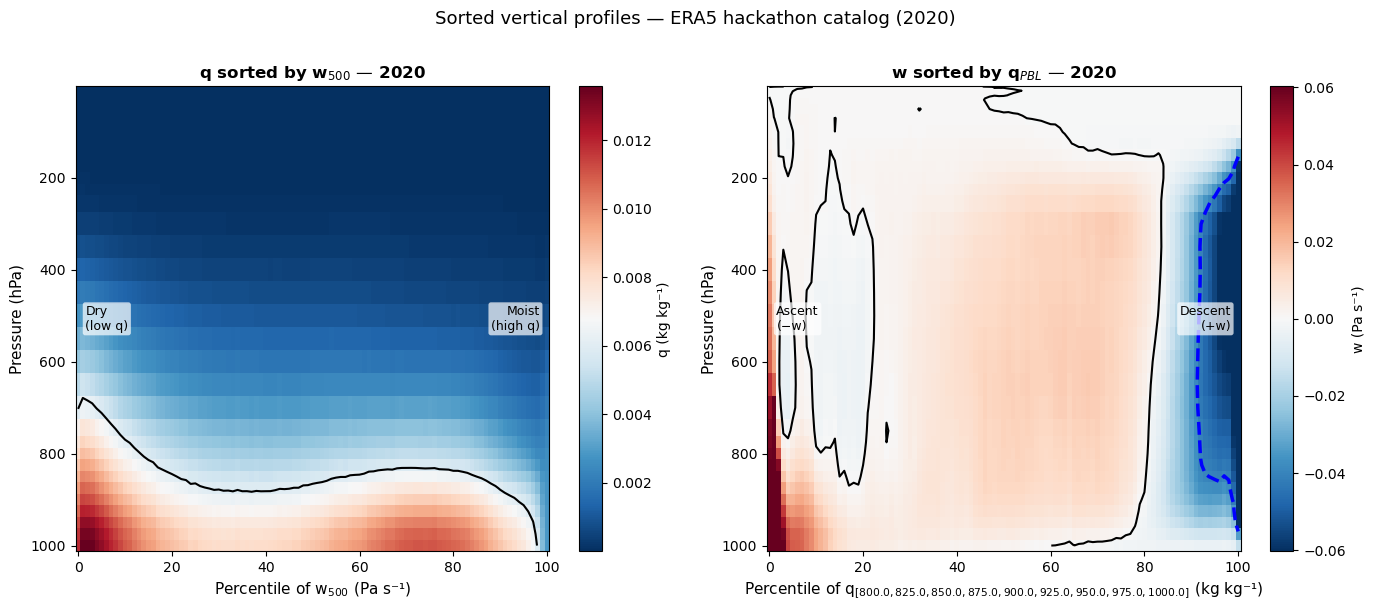

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: q sorted by w500
pcm1 = plot_sorted_profiles(
    q_sorted_by_w500_2020, axes[0],
    title  = "q sorted by w$_{500}$ — 2020",
    xlabel = "Percentile of w500",
    cmap   = "RdBu_r",
)
fig.colorbar(pcm1, ax=axes[0], label="q (kg kg⁻¹)")

# Panel 2: w sorted by q750
pcm2 = plot_sorted_profiles(
    w_sorted_by_qLT_2020, axes[1],
    title  = "w sorted by q$_{PBL}$ — 2020",
    xlabel = "Percentile of q$_{PBL}$",
    cmap   = "RdBu_r",
    center = 0,
)
fig.colorbar(pcm2, ax=axes[1], label="w (Pa s⁻¹)")

plt.suptitle("Sorted vertical profiles — ERA5 hackathon catalog (2020)", 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("sorted_profiles_2020.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
def plot_sorting_key(da_base, ax, base_level, time_slice=None, 
                     color="steelblue", label=None):
    """
    Plot the mean (across time) of the sorting key variable at base_level,
    binned by percentile — i.e. the x-axis variable of the sorted profiles.
    """
    if time_slice is not None:
        da_base = da_base.sel(time=time_slice)

    # extract level
    key = da_base.sel(level=base_level, method="nearest")  # (time, cell)

    # for each timestep, compute percentile values, then average across time
    percentiles = np.arange(0, 101, 1)
    pct_values  = np.nanpercentile(key.values, percentiles, axis=-1)  # (101, time)
    pct_mean    = pct_values.mean(axis=-1)   # (101,)
    pct_std     = pct_values.std(axis=-1)    # (101,) — spread across months

    var_name  = da_base.name
    units     = da_base.attrs.get("units", "")
    label     = label or f"{var_name}$_{{{base_level}}}$"

    ax.plot(percentiles, pct_mean, color=color, lw=2, label=label)
    # ax.fill_between(percentiles, pct_mean - pct_std, pct_mean + pct_std,
                    # alpha=0.25, color=color, label="±1σ across months")
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.axvline(50, color="grey", lw=0.8, ls=":")
    ax.set_xlabel("Percentile", fontsize=11)
    ax.set_ylabel(f"{label} ({units})", fontsize=11)
    ax.set_title(f"Sorting key: {label} by percentile — 2020", 
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

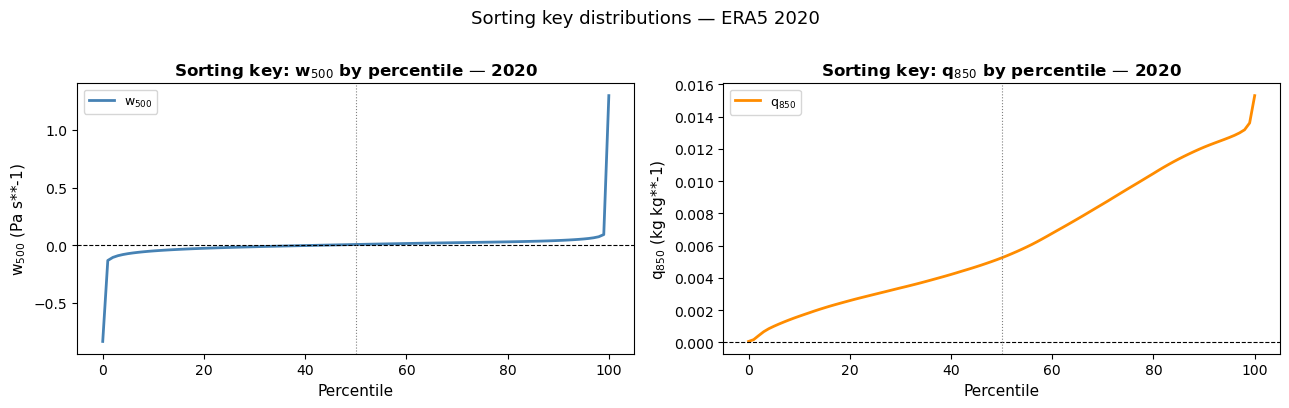

In [11]:
# ── plot ──────────────────────────────────────────────────────────────────────
t2020 = slice("2020-01", "2020-12")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_sorting_key(w, axes[0], base_level=500, time_slice=t2020, color="steelblue")
plot_sorting_key(q, axes[1], base_level=850, time_slice=t2020, color="darkorange")

plt.suptitle("Sorting key distributions — ERA5 2020", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("sorting_keys_2020.png", dpi=150, bbox_inches="tight")
plt.show()

Percentile of w$_{500}$ (Pa s⁻¹)
Percentile of q$_{[800.0, 825.0, 850.0, 875.0, 900.0, 925.0, 950.0, 975.0, 1000.0]}$ (kg kg⁻¹)


/tmp/ipykernel_2004/2101777479.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


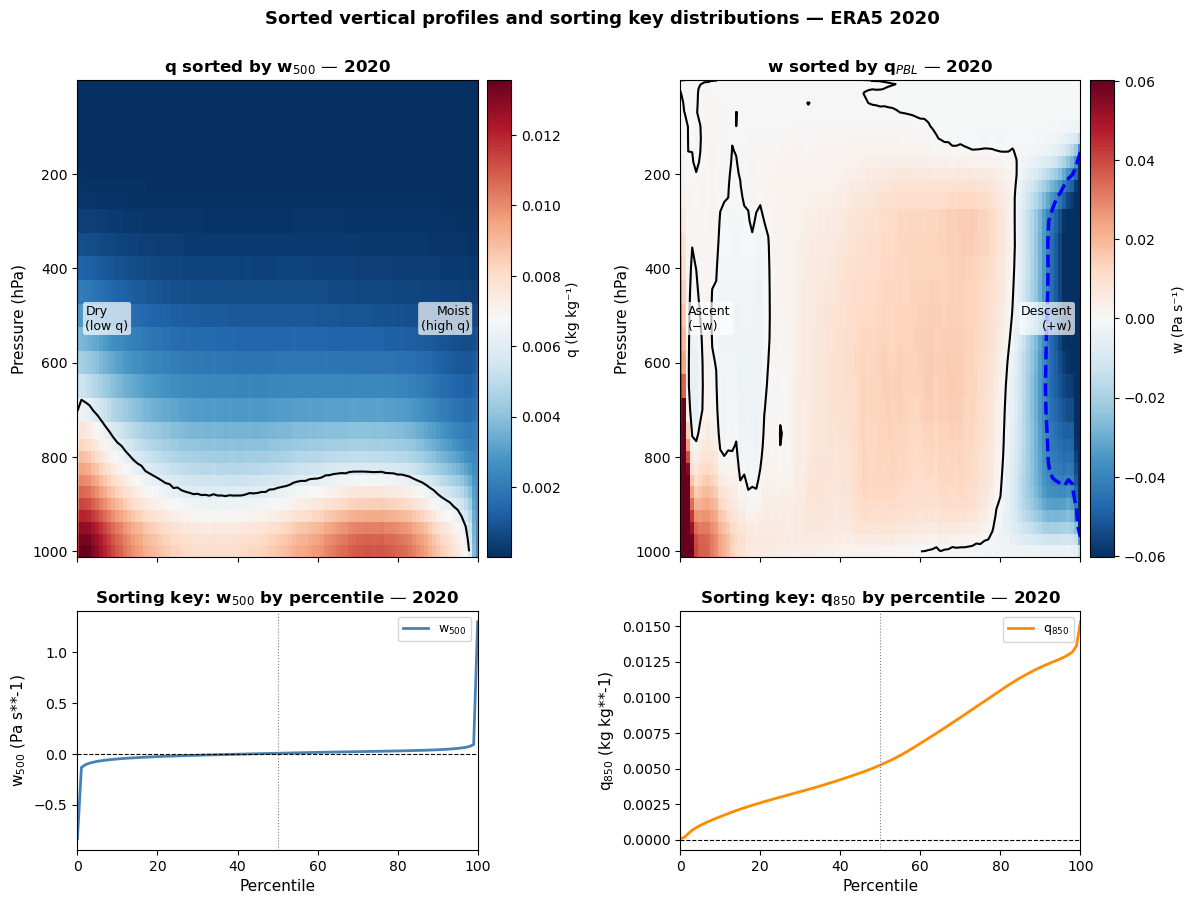

In [12]:
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[2, 1],   # top row twice the height of bottom row
    hspace=0.15,            # vertical space between rows
    wspace=0.25,            # horizontal space between columns
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ── Row 0: sorted profiles ────────────────────────────────────────────────────
pcm1 = plot_sorted_profiles(
    q_sorted_by_w500_2020, axes[0, 0],
    title  = "q sorted by w$_{500}$ — 2020",
    xlabel = "",
    cmap   = "RdBu_r",
)
fig.colorbar(pcm1, ax=axes[0, 0], label="q (kg kg⁻¹)", pad=0.02)

pcm2 = plot_sorted_profiles(
    w_sorted_by_qLT_2020, axes[0, 1],
    title  = "w sorted by q$_{PBL}$ — 2020",
    xlabel = "",
    cmap   = "RdBu_r",
    center = 0,
)
fig.colorbar(pcm2, ax=axes[0, 1], label="w (Pa s⁻¹)", pad=0.02)

# remove x tick labels on top row so bottom row x-axis is the reference
for ax in axes[0]:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=False)

# ── Row 1: sorting keys ───────────────────────────────────────────────────────
plot_sorting_key(w, axes[1, 0], base_level=500, time_slice=t2020, color="steelblue")
plot_sorting_key(q, axes[1, 1], base_level=850, time_slice=t2020, color="darkorange")

# enforce identical x limits across all columns so percentiles align
for col in range(2):
    axes[0, col].set_xlim(0, 100)
    axes[1, col].set_xlim(0, 100)

plt.suptitle("Sorted vertical profiles and sorting key distributions — ERA5 2020",
             fontsize=13, fontweight="bold", y=0.95)
plt.tight_layout()

# ── force same left/right edges for both columns so widths truly match ────────
# (colorbar on top row shifts its axes; this corrects for that)
for col in range(2):
    pos_top = axes[0, col].get_position()
    pos_bot = axes[1, col].get_position()
    axes[1, col].set_position([
        pos_top.x0,           # align left edge
        pos_bot.y0,           # keep vertical position
        pos_top.width,        # match width exactly
        pos_bot.height,       # keep its own height
    ])

plt.savefig("4panel_sorted_profiles_2020.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
def crop_by_latitude(lat_bounds, *data_arrays):
    """
    Crop one or more xarray DataArrays by latitude bounds.

    Parameters
    ----------
    lat_bounds : tuple[float, float] | None
        (lat_min, lat_max) to retain, or None to skip cropping.
    *data_arrays : xr.DataArray
        Any number of DataArrays sharing the same 'cell' and 'lat' dimensions.

    Returns
    -------
    list[xr.DataArray]
        Cropped DataArrays in the same order as provided.
        If lat_bounds is None, returns the originals unchanged.
    """
    if lat_bounds is None:
        return list(data_arrays)

    lat_min, lat_max = lat_bounds

    # Use the lat coordinate from the first array (assumed shared across all)
    lat = data_arrays[0].lat.compute()
    cell_mask = ((lat >= lat_min) & (lat <= lat_max)).compute()

    cropped = [da.isel(cell=cell_mask) for da in data_arrays]

    print(
        f"  Cropped to lat [{lat_min}, {lat_max}]: "
        f"{int(cell_mask.sum())} / {len(cell_mask)} cells retained"
    )

    return cropped

In [14]:
lat_bounds=(-30,30)
w_trop, q_trop = crop_by_latitude(lat_bounds, w, q)

  Cropped to lat [-30, 30]: 98816 / 196608 cells retained


Percentile of w$_{500}$ (Pa s⁻¹)
Percentile of q$_{[800.0, 825.0, 850.0, 875.0, 900.0, 925.0, 950.0, 975.0, 1000.0]}$ (kg kg⁻¹)


/tmp/ipykernel_2004/132157484.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


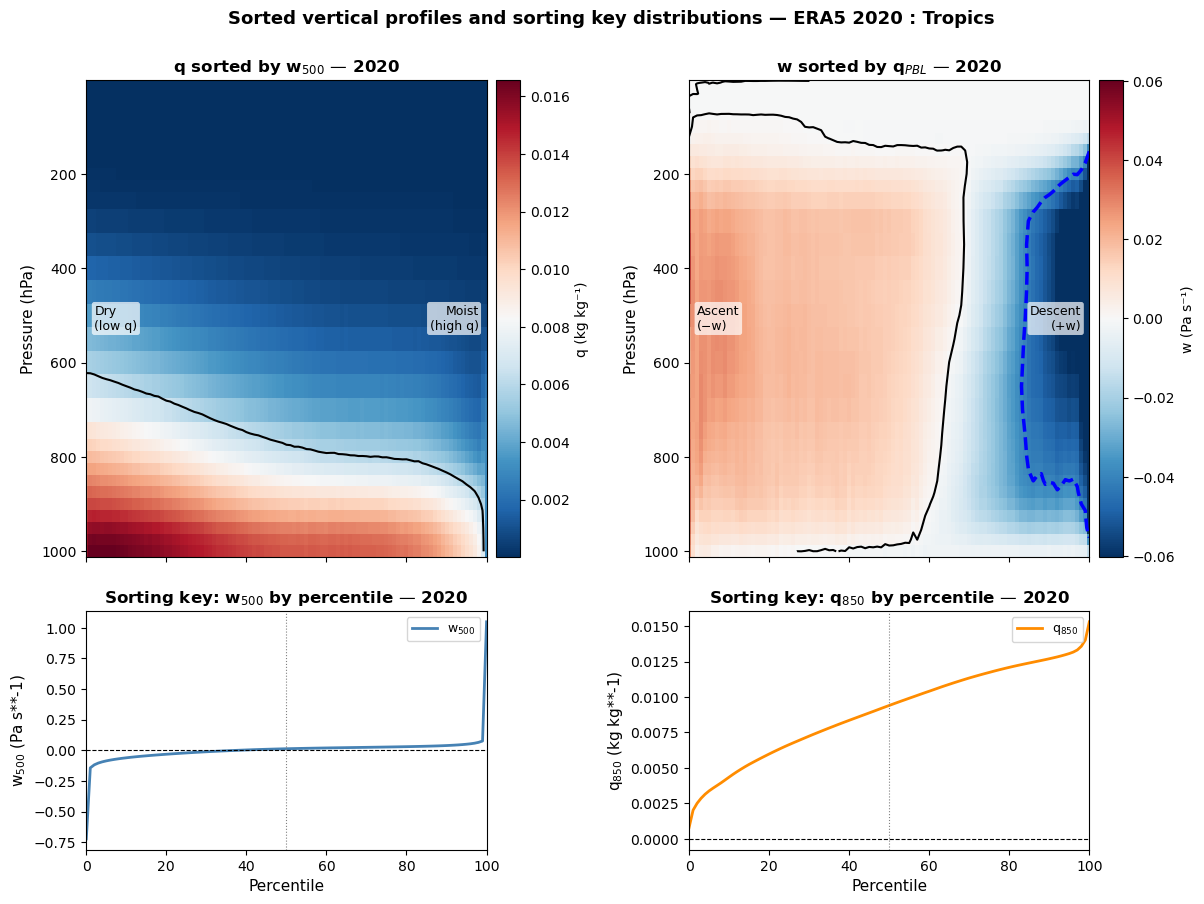

In [15]:
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[2, 1],   # top row twice the height of bottom row
    hspace=0.15,            # vertical space between rows
    wspace=0.25,            # horizontal space between columns
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ── Row 0: sorted profiles ────────────────────────────────────────────────────
pcm1 = plot_sorted_profiles(
    q_sorted_by_w500_2020_tropics, axes[0, 0],
    title  = "q sorted by w$_{500}$ — 2020",
    xlabel = "",
    cmap   = "RdBu_r",
)
fig.colorbar(pcm1, ax=axes[0, 0], label="q (kg kg⁻¹)", pad=0.02)

pcm2 = plot_sorted_profiles(
    w_sorted_by_qLT_2020_tropics, axes[0, 1],
    title  = "w sorted by q$_{PBL}$ — 2020",
    xlabel = "",
    cmap   = "RdBu_r",
    center = 0,
)
fig.colorbar(pcm2, ax=axes[0, 1], label="w (Pa s⁻¹)", pad=0.02)

# remove x tick labels on top row so bottom row x-axis is the reference
for ax in axes[0]:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=False)

# ── Row 1: sorting keys ───────────────────────────────────────────────────────
plot_sorting_key(w_trop, axes[1, 0], base_level=500, time_slice=t2020, color="steelblue")
plot_sorting_key(q_trop, axes[1, 1], base_level=850, time_slice=t2020, color="darkorange")

# enforce identical x limits across all columns so percentiles align
for col in range(2):
    axes[0, col].set_xlim(0, 100)
    axes[1, col].set_xlim(0, 100)

plt.suptitle("Sorted vertical profiles and sorting key distributions — ERA5 2020 : Tropics",
             fontsize=13, fontweight="bold", y=0.95)
plt.tight_layout()

# ── force same left/right edges for both columns so widths truly match ────────
# (colorbar on top row shifts its axes; this corrects for that)
for col in range(2):
    pos_top = axes[0, col].get_position()
    pos_bot = axes[1, col].get_position()
    axes[1, col].set_position([
        pos_top.x0,           # align left edge
        pos_bot.y0,           # keep vertical position
        pos_top.width,        # match width exactly
        pos_bot.height,       # keep its own height
    ])

plt.savefig("4panel_sorted_profiles_2020_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

# Warm El Nino Year 2016

In [16]:
ElNinoYrs=[1983,1987,1988,1992,1995,1998,2003,2007,2010,2016]

In [17]:
ElNinoYrs=[1983,1987,1988,1992,1995,1998,2003,2007,2010,2016]

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── select 2020 ───────────────────────────────────────────────────────────────
t2016 = slice("2016-01", "2016-12")

# Sort q profiles by w at 500 hPa : tropics only
q_sorted_by_w500_2016_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = q,
    base_level = 500,
    time_slice = t2016,
    lat_bounds = (-30, 30),          # ← tropics
    output_file= "q_sorted_by_w500_2016_tropics_ElNino.nc",
)

# tropics only
w_sorted_by_qLT_2016_tropics = sort_profiles_by_level(
    da_base    = q,
    da_target  = w,
    base_level = [800.,  825., 850.,  875.,  900.,  925.,  950.,  975., 1000.],
    time_slice = t2016,
    lat_bounds = (-30, 30),          # ← tropics
    output_file= "w_sorted_by_qLT_2016_tropics_ElNino.nc",
)

File exists, loading: q_sorted_by_w500_2016_tropics_ElNino.nc
File exists, loading: w_sorted_by_qLT_2016_tropics_ElNino.nc


Percentile of w$_{500}$ (Pa s⁻¹)
Percentile of q$_{800–1000}$ (kg kg⁻¹)


/tmp/ipykernel_2004/1000381794.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


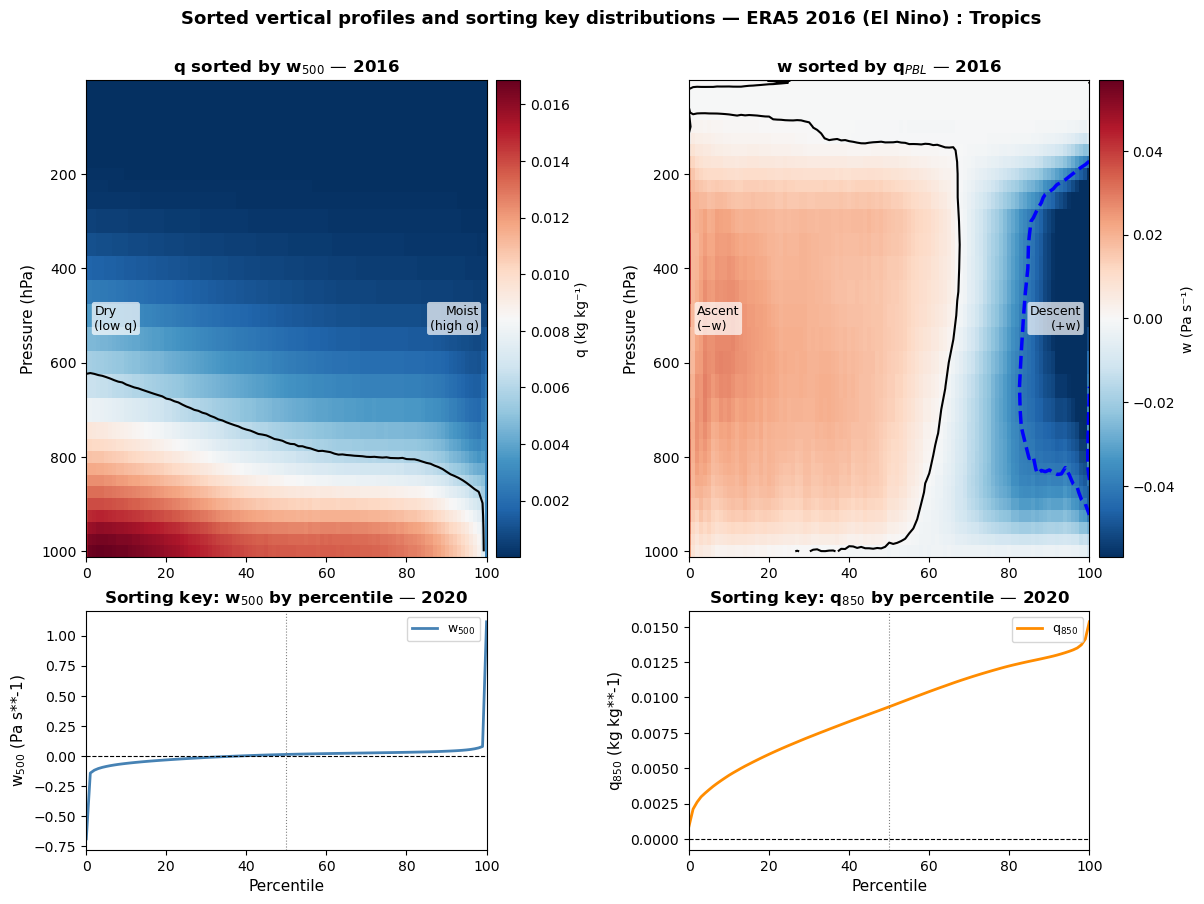

In [18]:
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[2, 1],   # top row twice the height of bottom row
    hspace=0.15,            # vertical space between rows
    wspace=0.25,            # horizontal space between columns
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ── Row 0: sorted profiles ────────────────────────────────────────────────────
pcm1 = plot_sorted_profiles(
    q_sorted_by_w500_2016_tropics, axes[0, 0],
    title  = "q sorted by w$_{500}$ — 2016",
    xlabel = "",
    cmap   = "RdBu_r",
)
fig.colorbar(pcm1, ax=axes[0, 0], label="q (kg kg⁻¹)", pad=0.02)

pcm2 = plot_sorted_profiles(
    w_sorted_by_qLT_2016_tropics, axes[0, 1],
    title  = "w sorted by q$_{PBL}$ — 2016",
    xlabel = "",
    cmap   = "RdBu_r",
    center = 0,
)
fig.colorbar(pcm2, ax=axes[0, 1], label="w (Pa s⁻¹)", pad=0.02)

# remove x tick labels on top row so bottom row x-axis is the reference
for ax in axes[0]:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=True)

# ── Row 1: sorting keys ───────────────────────────────────────────────────────
plot_sorting_key(w_trop, axes[1, 0], base_level=500, time_slice=t2016, color="steelblue")
plot_sorting_key(q_trop, axes[1, 1], base_level=850, time_slice=t2016, color="darkorange")

# enforce identical x limits across all columns so percentiles align
for col in range(2):
    axes[0, col].set_xlim(0, 100)
    axes[1, col].set_xlim(0, 100)

plt.suptitle("Sorted vertical profiles and sorting key distributions — ERA5 2016 (El Nino) : Tropics",
             fontsize=13, fontweight="bold", y=0.95)
plt.tight_layout()

# ── force same left/right edges for both columns so widths truly match ────────
# (colorbar on top row shifts its axes; this corrects for that)
for col in range(2):
    pos_top = axes[0, col].get_position()
    pos_bot = axes[1, col].get_position()
    axes[1, col].set_position([
        pos_top.x0,           # align left edge
        pos_bot.y0,           # keep vertical position
        pos_top.width,        # match width exactly
        pos_bot.height,       # keep its own height
    ])

plt.savefig("4panel_sorted_profiles_2016_tropics_ElNino.png", dpi=150, bbox_inches="tight")
plt.show()

# Cold La Nina Year 2008

In [19]:
LaNinaYrs=[1974,1976,1989,1999,2000,2008,2011,2012,2021,2022]

In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── select 2020 ───────────────────────────────────────────────────────────────
t2008 = slice("2008-01", "2008-12")

# Sort q profiles by w at 500 hPa : tropics only
q_sorted_by_w500_2008_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = q,
    base_level = 500,
    time_slice = t2008,
    lat_bounds = (-30, 30),          # ← tropics
    output_file= "q_sorted_by_w500_2008_tropics_ElNino.nc",
)

# tropics only
w_sorted_by_qLT_2008_tropics = sort_profiles_by_level(
    da_base    = q,
    da_target  = w,
    base_level = [800.,  825., 850.,  875.,  900.,  925.,  950.,  975., 1000.],
    time_slice = t2008,
    lat_bounds = (-30, 30),          # ← tropics
    output_file= "w_sorted_by_qLT_2008_tropics_ElNino.nc",
)

File exists, loading: q_sorted_by_w500_2008_tropics_ElNino.nc
File exists, loading: w_sorted_by_qLT_2008_tropics_ElNino.nc


Percentile of w$_{500}$ (Pa s⁻¹)
Percentile of q$_{[800.0, 825.0, 850.0, 875.0, 900.0, 925.0, 950.0, 975.0, 1000.0]}$ (kg kg⁻¹)


/tmp/ipykernel_2004/1514950881.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


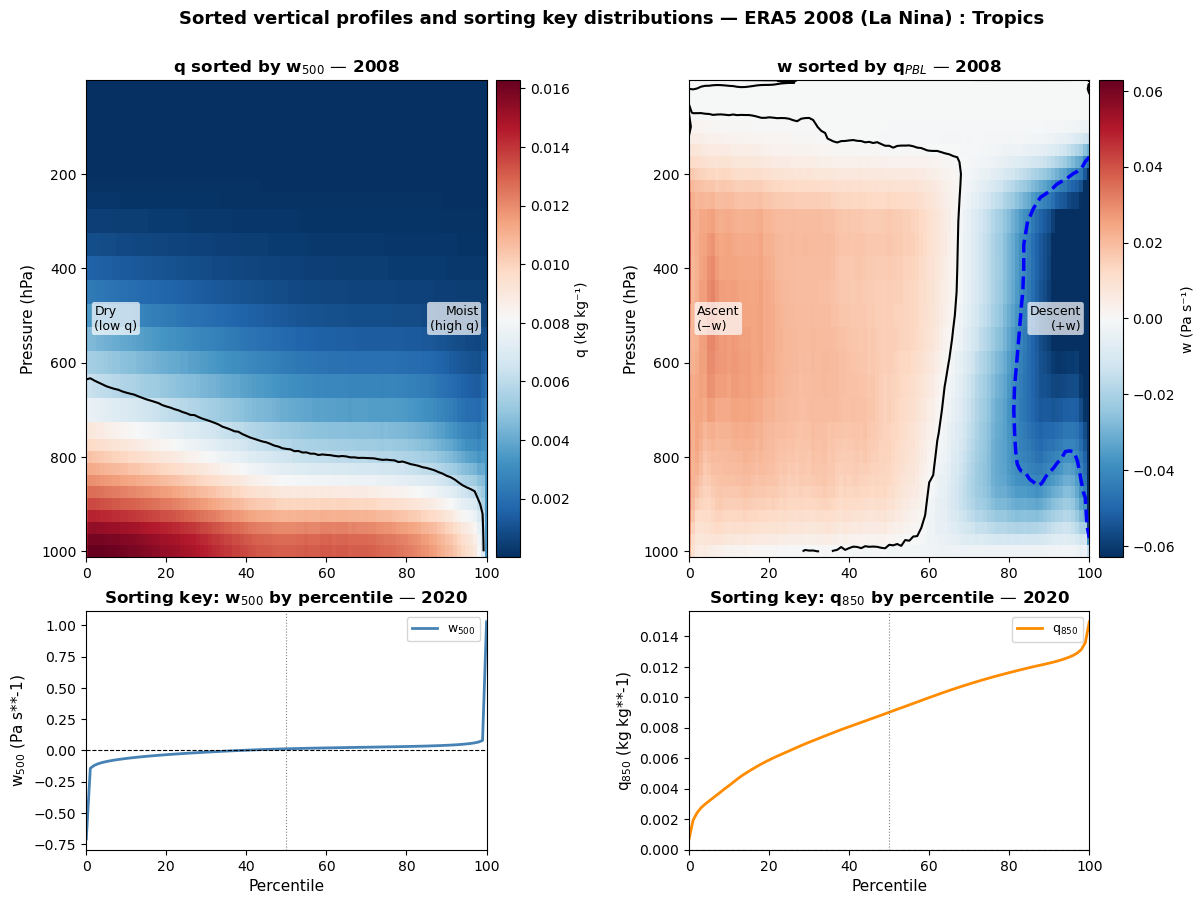

In [21]:
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[2, 1],   # top row twice the height of bottom row
    hspace=0.15,            # vertical space between rows
    wspace=0.25,            # horizontal space between columns
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ── Row 0: sorted profiles ────────────────────────────────────────────────────
pcm1 = plot_sorted_profiles(
    q_sorted_by_w500_2008_tropics, axes[0, 0],
    title  = "q sorted by w$_{500}$ — 2008",
    xlabel = "",
    cmap   = "RdBu_r",
)
fig.colorbar(pcm1, ax=axes[0, 0], label="q (kg kg⁻¹)", pad=0.02)

pcm2 = plot_sorted_profiles(
    w_sorted_by_qLT_2008_tropics, axes[0, 1],
    title  = "w sorted by q$_{PBL}$ — 2008",
    xlabel = "",
    cmap   = "RdBu_r",
    center = 0,
)
fig.colorbar(pcm2, ax=axes[0, 1], label="w (Pa s⁻¹)", pad=0.02)

# remove x tick labels on top row so bottom row x-axis is the reference
for ax in axes[0]:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=True)

# ── Row 1: sorting keys ───────────────────────────────────────────────────────
plot_sorting_key(w_trop, axes[1, 0], base_level=500, time_slice=t2008, color="steelblue")
plot_sorting_key(q_trop, axes[1, 1], base_level=850, time_slice=t2008, color="darkorange")

# enforce identical x limits across all columns so percentiles align
for col in range(2):
    axes[0, col].set_xlim(0, 100)
    axes[1, col].set_xlim(0, 100)

plt.suptitle("Sorted vertical profiles and sorting key distributions — ERA5 2008 (La Nina) : Tropics",
             fontsize=13, fontweight="bold", y=0.95)
plt.tight_layout()

# ── force same left/right edges for both columns so widths truly match ────────
# (colorbar on top row shifts its axes; this corrects for that)
for col in range(2):
    pos_top = axes[0, col].get_position()
    pos_bot = axes[1, col].get_position()
    axes[1, col].set_position([
        pos_top.x0,           # align left edge
        pos_bot.y0,           # keep vertical position
        pos_top.width,        # match width exactly
        pos_bot.height,       # keep its own height
    ])

plt.savefig("4panel_sorted_profiles_2008_tropics_LaNina.png", dpi=150, bbox_inches="tight")
plt.show()

# El Nino minus La Nina

In [22]:
def plot_4panel_sorted_profiles(
    q_sorted_by_w500, w_sorted_by_qLT,
    w_trop, q_trop,
    time_slice,
    suptitle, savepath,
    q_label="q (kg kg⁻¹)", w_label="w (Pa s⁻¹)",
):
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(
        2, 2,
        height_ratios=[2, 1],
        hspace=0.15,
        wspace=0.25,
    )
    axes = np.array([
        [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
    ])

    # ── Row 0: sorted profiles ────────────────────────────────────────────────
    pcm1 = plot_sorted_profiles(
        q_sorted_by_w500, axes[0, 0],
        title  = f"q sorted by w$_{{500}}$",
        xlabel = "",
        cmap   = "RdBu_r",
    )
    fig.colorbar(pcm1, ax=axes[0, 0], label=q_label, pad=0.02)

    pcm2 = plot_sorted_profiles(
        w_sorted_by_qLT, axes[0, 1],
        title  = f"w sorted by q$_{PBL}$",
        xlabel = "",
        cmap   = "RdBu_r",
        center = 0,
    )
    fig.colorbar(pcm2, ax=axes[0, 1], label=w_label, pad=0.02)

    for ax in axes[0]:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=True)

    # ── Row 1: sorting keys ───────────────────────────────────────────────────
    plot_sorting_key(w_trop, axes[1, 0], base_level=500, time_slice=time_slice, color="steelblue")
    plot_sorting_key(q_trop, axes[1, 1], base_level=850, time_slice=time_slice, color="darkorange")

    for col in range(2):
        axes[0, col].set_xlim(0, 100)
        axes[1, col].set_xlim(0, 100)

    plt.suptitle(suptitle, fontsize=13, fontweight="bold", y=0.95)
    plt.tight_layout()

    for col in range(2):
        pos_top = axes[0, col].get_position()
        pos_bot = axes[1, col].get_position()
        axes[1, col].set_position([
            pos_top.x0,
            pos_bot.y0,
            pos_top.width,
            pos_bot.height,
        ])

    plt.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()

def plot_4panel_difference(
    q_sorted_by_w500_elnino, q_sorted_by_w500_lanina,
    w_sorted_by_qLT_elnino,  w_sorted_by_qLT_lanina,
    w_trop_elnino, w_trop_lanina,
    q_trop_elnino, q_trop_lanina,
    t_elnino, t_lanina,
    suptitle="Sorted vertical profiles — El Niño minus La Niña : Tropics",
    savepath="4panel_difference_ElNino_minus_LaNina_tropics_1event.png",
):
    # ── compute differences ───────────────────────────────────────────────────
    q_diff = q_sorted_by_w500_elnino.mean("time") - q_sorted_by_w500_lanina.mean("time")
    w_diff = w_sorted_by_qLT_elnino.mean("time")  - w_sorted_by_qLT_lanina.mean("time")
    # q_diff = q_sorted_by_w500_2016_tropics.mean("time") - q_sorted_by_w500_2008_tropics.mean("time")
    # w_diff = w_sorted_by_qLT_2016_tropics.mean("time")  - w_sorted_by_qLT_2008_tropics.mean("time")
    # # plot_sorted_profiles expects a 'time' dim — add a dummy one
    q_diff = q_diff.expand_dims("time")
    w_diff = w_diff.expand_dims("time")

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(
        2, 2,
        height_ratios=[2, 1],
        hspace=0.15,
        wspace=0.25,
    )
    axes = np.array([
        [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
    ])

    # ── Row 0: difference profiles ────────────────────────────────────────────
    # Symmetric colour limits so zero is white
    qlim = float(np.nanpercentile(np.abs(q_diff), 98))
    wlim = float(np.nanpercentile(np.abs(w_diff), 98))

    pcm1 = plot_sorted_profiles(
        q_diff, axes[0, 0],
        title  = "Δq sorted by w$_{500}$  (El Niño − La Niña)",
        xlabel = "",
        cmap   = "RdBu_r",
        center = 0,
        vmin=-qlim, vmax=qlim,          # pass through if your function accepts them
    )
    fig.colorbar(pcm1, ax=axes[0, 0], label="Δq (kg kg⁻¹)", pad=0.02)

    pcm2 = plot_sorted_profiles(
        w_diff, axes[0, 1],
        title  = "Δw sorted by q$_{PBL}$  (El Niño − La Niña)",
        xlabel = "",
        cmap   = "RdBu_r",
        center = 0,
        vmin=-wlim, vmax=wlim,
    )
    fig.colorbar(pcm2, ax=axes[0, 1], label="Δw (Pa s⁻¹)", pad=0.02)

    for ax in axes[0]:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=True)

    # ── Row 1: both sorting-key distributions overlaid ────────────────────────
    # ── Row 1: both sorting-key distributions overlaid ────────────────────────
    plot_sorting_key(w_trop_elnino, axes[1, 0], base_level=500,
                     time_slice=t_elnino, color="steelblue")
    plot_sorting_key(w_trop_lanina, axes[1, 0], base_level=500,
                     time_slice=t_lanina, color="steelblue")
    
    # Retroactively style the two lines: first call → solid, second call → dashed
    lines = axes[1, 0].get_lines()
    lines[-2].set_linestyle("-");  lines[-2].set_label("El Niño")
    lines[-1].set_linestyle("--"); lines[-1].set_alpha(0.6); lines[-1].set_label("La Niña")
    axes[1, 0].legend(fontsize=8)
    
    plot_sorting_key(q_trop_elnino, axes[1, 1], base_level=850,
                     time_slice=t_elnino, color="darkorange")
    plot_sorting_key(q_trop_lanina, axes[1, 1], base_level=850,
                     time_slice=t_lanina, color="darkorange")
    
    lines = axes[1, 1].get_lines()
    lines[-2].set_linestyle("-");  lines[-2].set_label("El Niño")
    lines[-1].set_linestyle("--"); lines[-1].set_alpha(0.6); lines[-1].set_label("La Niña")
    axes[1, 1].legend(fontsize=8)

    for col in range(2):
        axes[0, col].set_xlim(0, 100)
        axes[1, col].set_xlim(0, 100)

    plt.suptitle(suptitle, fontsize=13, fontweight="bold", y=0.95)
    plt.tight_layout()

    for col in range(2):
        pos_top = axes[0, col].get_position()
        pos_bot = axes[1, col].get_position()
        axes[1, col].set_position([
            pos_top.x0,
            pos_bot.y0,
            pos_top.width,
            pos_bot.height,
        ])

    plt.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()

Percentile of 
Percentile of 


/tmp/ipykernel_2004/823573116.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


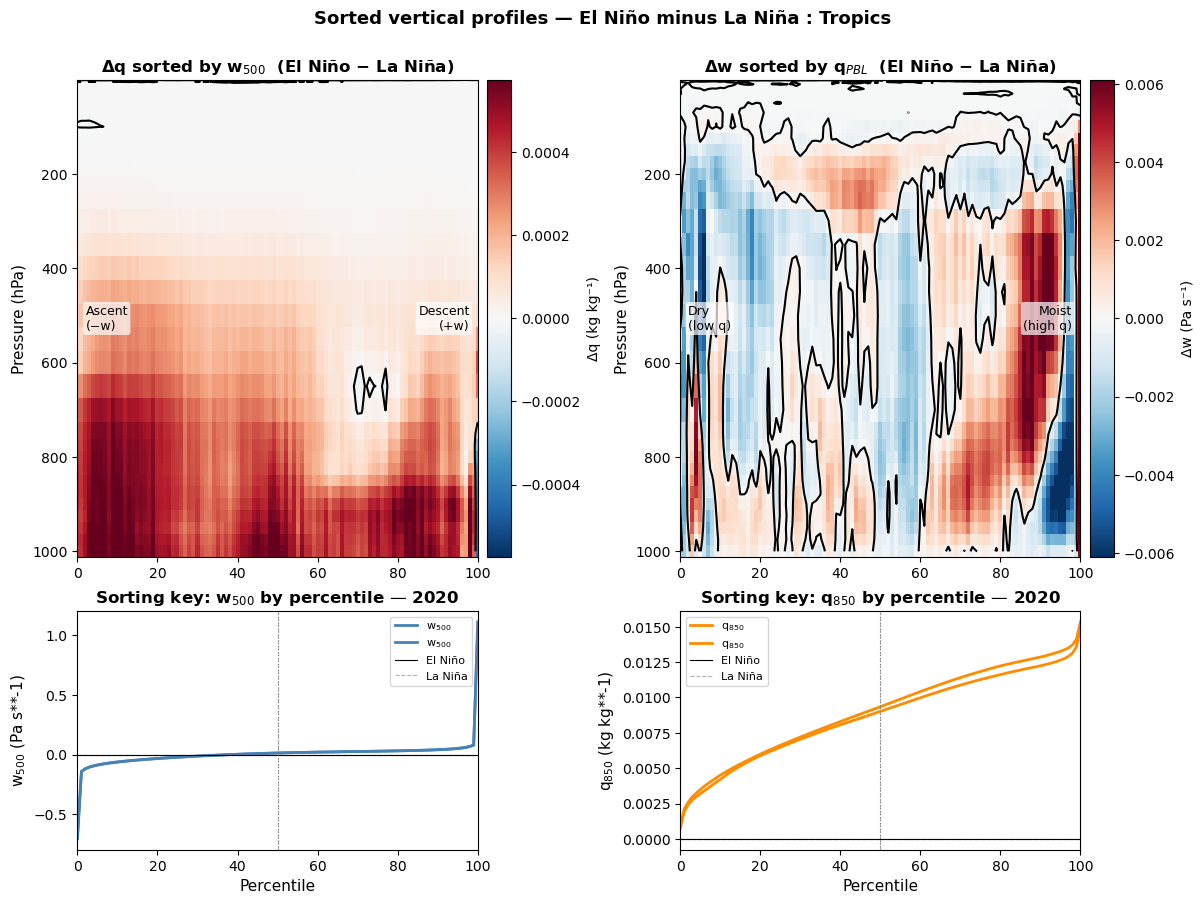

In [23]:
plot_4panel_difference(
    q_sorted_by_w500_2016_tropics, q_sorted_by_w500_2008_tropics,
    w_sorted_by_qLT_2016_tropics,  w_sorted_by_qLT_2008_tropics,
    w_trop, w_trop,
    q_trop, q_trop,
    t2016, t2008,
)

In [24]:
print(q_sorted_by_w500_2016_tropics.dims, q_sorted_by_w500_2016_tropics.shape)
print(q_sorted_by_w500_2008_tropics.dims, q_sorted_by_w500_2008_tropics.shape)

print(q_sorted_by_w500_2016_tropics.coords)
print(q_sorted_by_w500_2008_tropics.coords)

('time', 'level', 'percentile') (12, 37, 101)
('time', 'level', 'percentile') (12, 37, 101)
Coordinates:
  * time        (time) datetime64[ns] 96B 2016-01-01 2016-02-01 ... 2016-12-01
  * level       (level) float32 148B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * percentile  (percentile) int64 808B 0 1 2 3 4 5 6 ... 94 95 96 97 98 99 100
Coordinates:
  * time        (time) datetime64[ns] 96B 2008-01-01 2008-02-01 ... 2008-12-01
  * level       (level) float32 148B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * percentile  (percentile) int64 808B 0 1 2 3 4 5 6 ... 94 95 96 97 98 99 100


# El Nino composite

In [25]:
# event year list from: https://psl.noaa.gov/enso/past_events.html

In [26]:
ElNinoYrs = [1983, 1987, 1988, 1992, 1995, 1998, 2003, 2007, 2010, 2016]

# Build a boolean mask selecting all months in El Niño years
elnino_mask = w.time.dt.year.isin(ElNinoYrs).compute()
elnino_times = w.time.isel(time=elnino_mask)
print(f"El Niño months: {int(elnino_mask.sum())} "
      f"({ElNinoYrs[0]}–{ElNinoYrs[-1]})")

# Sort q profiles by w500 — El Niño composite, tropics
q_sorted_elnino_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = q,
    base_level = 500,
    time_slice = elnino_mask,        # ← pass the boolean mask directly
    lat_bounds = (-30, 30),
    output_file= "q_sorted_by_w500_elnino_tropics.nc",
)

# Sort w profiles by lower-tropospheric q — El Niño composite, tropics
w_sorted_elnino_tropics = sort_profiles_by_level(
    da_base    = q,
    da_target  = w,
    base_level = [800., 825., 850., 875., 900., 925., 950., 975., 1000.],
    time_slice = elnino_mask,
    lat_bounds = (-30, 30),
    output_file= "w_sorted_by_qLT_elnino_tropics.nc",
)

El Niño months: 120 (1983–2016)
File exists, loading: q_sorted_by_w500_elnino_tropics.nc
File exists, loading: w_sorted_by_qLT_elnino_tropics.nc


Percentile of w$_{500}$ (Pa s⁻¹)
Percentile of q$_{800–1000}$ (kg kg⁻¹)


/tmp/ipykernel_2004/1779464906.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


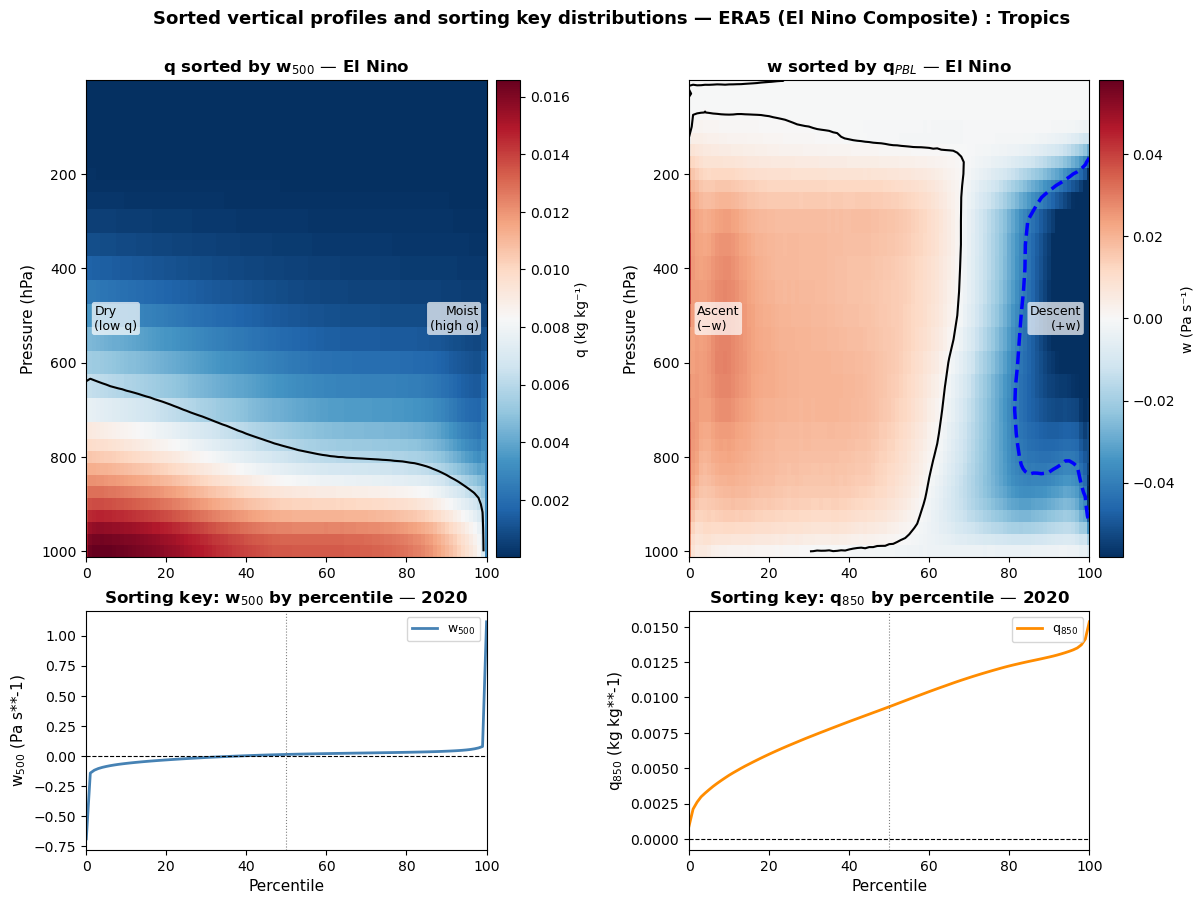

In [27]:
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[2, 1],   # top row twice the height of bottom row
    hspace=0.15,            # vertical space between rows
    wspace=0.25,            # horizontal space between columns
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ── Row 0: sorted profiles ────────────────────────────────────────────────────
pcm1 = plot_sorted_profiles(
    q_sorted_elnino_tropics, axes[0, 0],
    title  = "q sorted by w$_{500}$ — El Nino",
    xlabel = "",
    cmap   = "RdBu_r",
)
fig.colorbar(pcm1, ax=axes[0, 0], label="q (kg kg⁻¹)", pad=0.02)

pcm2 = plot_sorted_profiles(
    w_sorted_elnino_tropics, axes[0, 1],
    title  = "w sorted by q$_{PBL}$ — El Nino",
    xlabel = "",
    cmap   = "RdBu_r",
    center = 0,
)
fig.colorbar(pcm2, ax=axes[0, 1], label="w (Pa s⁻¹)", pad=0.02)

# remove x tick labels on top row so bottom row x-axis is the reference
for ax in axes[0]:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=True)

# ── Row 1: sorting keys ───────────────────────────────────────────────────────
plot_sorting_key(w_trop, axes[1, 0], base_level=500, time_slice=t2016, color="steelblue")
plot_sorting_key(q_trop, axes[1, 1], base_level=850, time_slice=t2016, color="darkorange")

# enforce identical x limits across all columns so percentiles align
for col in range(2):
    axes[0, col].set_xlim(0, 100)
    axes[1, col].set_xlim(0, 100)

plt.suptitle("Sorted vertical profiles and sorting key distributions — ERA5 (El Nino Composite) : Tropics",
             fontsize=13, fontweight="bold", y=0.95)
plt.tight_layout()

# ── force same left/right edges for both columns so widths truly match ────────
# (colorbar on top row shifts its axes; this corrects for that)
for col in range(2):
    pos_top = axes[0, col].get_position()
    pos_bot = axes[1, col].get_position()
    axes[1, col].set_position([
        pos_top.x0,           # align left edge
        pos_bot.y0,           # keep vertical position
        pos_top.width,        # match width exactly
        pos_bot.height,       # keep its own height
    ])

plt.savefig("4panel_sorted_profiles_composite_tropics_ElNino.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# ElNinoYrs = [1983, 1987, 1988, 1992, 1995, 1998, 2003, 2007, 2010, 2016]
LaNinaYrs = [1974, 1976, 1989, 1999, 2000, 2008, 2011, 2012, 2021, 2022]

# Build a boolean mask selecting all months in El Niño years
lanina_mask = w.time.dt.year.isin(LaNinaYrs).compute()
lanina_times = w.time.isel(time=lanina_mask)
print(f"La Niña months: {int(lanina_mask.sum())} "
      f"({LaNinaYrs[0]}–{LaNinaYrs[-1]})")

# Sort q profiles by w500 — La Niña composite, tropics
q_sorted_lanina_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = q,
    base_level = 500,
    time_slice = lanina_mask,        # ← pass the boolean mask directly
    lat_bounds = (-30, 30),
    output_file= "q_sorted_by_w500_lanina_tropics.nc",
)

# Sort w profiles by lower-tropospheric q — El Niño composite, tropics
w_sorted_lanina_tropics = sort_profiles_by_level(
    da_base    = q,
    da_target  = w,
    base_level = [800., 825., 850., 875., 900., 925., 950., 975., 1000.],
    time_slice = lanina_mask,
    lat_bounds = (-30, 30),
    output_file= "w_sorted_by_qLT_lanina_tropics.nc",
)

La Niña months: 120 (1974–2022)
File exists, loading: q_sorted_by_w500_lanina_tropics.nc
File exists, loading: w_sorted_by_qLT_lanina_tropics.nc


Percentile of w$_{500}$ (Pa s⁻¹)
Percentile of q$_{800–1000}$ (kg kg⁻¹)


/tmp/ipykernel_2004/933914457.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


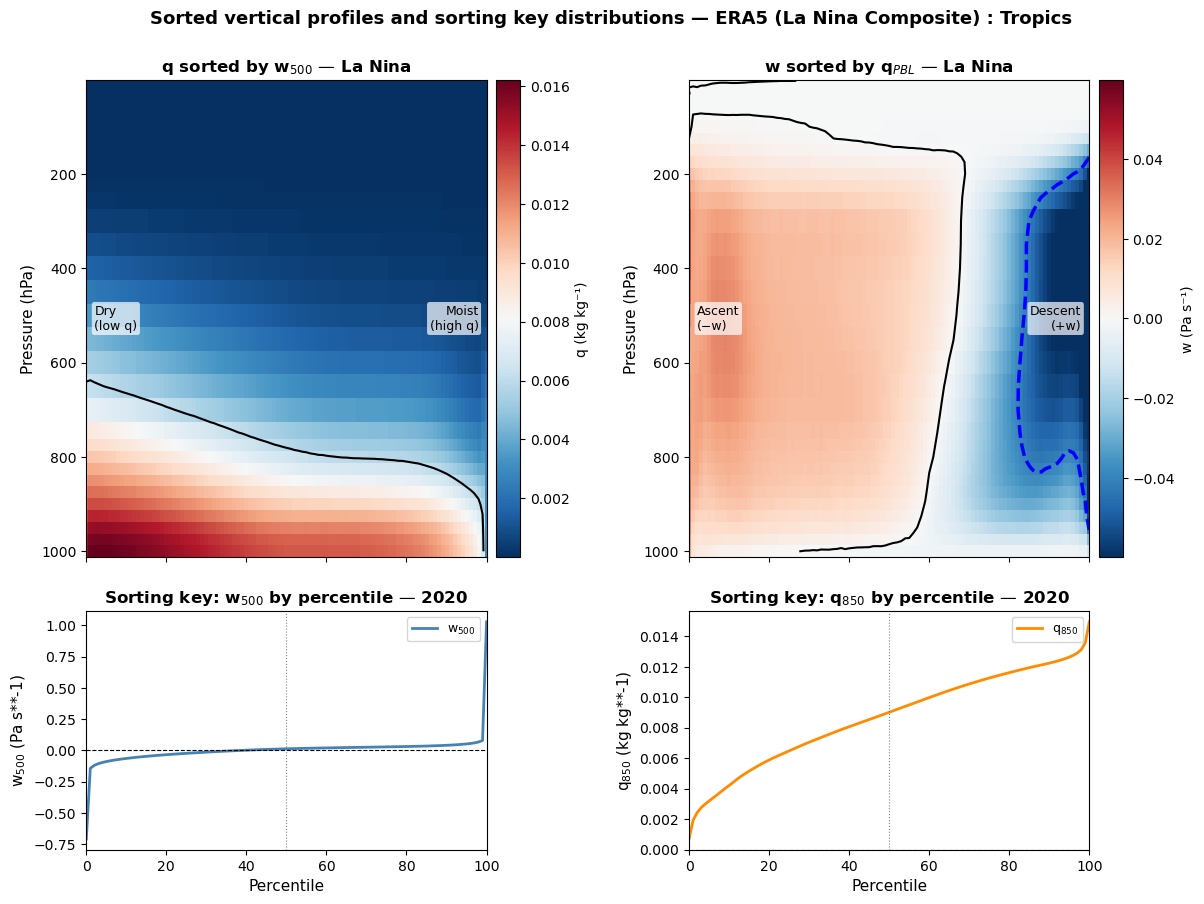

In [29]:
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[2, 1],   # top row twice the height of bottom row
    hspace=0.15,            # vertical space between rows
    wspace=0.25,            # horizontal space between columns
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ── Row 0: sorted profiles ────────────────────────────────────────────────────
pcm1 = plot_sorted_profiles(
    q_sorted_lanina_tropics, axes[0, 0],
    title  = "q sorted by w$_{500}$ — La Nina",
    xlabel = "",
    cmap   = "RdBu_r",
)
fig.colorbar(pcm1, ax=axes[0, 0], label="q (kg kg⁻¹)", pad=0.02)

pcm2 = plot_sorted_profiles(
    w_sorted_lanina_tropics, axes[0, 1],
    title  = "w sorted by q$_{PBL}$ — La Nina",
    xlabel = "",
    cmap   = "RdBu_r",
    center = 0,
)
fig.colorbar(pcm2, ax=axes[0, 1], label="w (Pa s⁻¹)", pad=0.02)

# remove x tick labels on top row so bottom row x-axis is the reference
for ax in axes[0]:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=False)

# ── Row 1: sorting keys ───────────────────────────────────────────────────────
plot_sorting_key(w_trop, axes[1, 0], base_level=500, time_slice=t2008, color="steelblue")
plot_sorting_key(q_trop, axes[1, 1], base_level=850, time_slice=t2008, color="darkorange")

# enforce identical x limits across all columns so percentiles align
for col in range(2):
    axes[0, col].set_xlim(0, 100)
    axes[1, col].set_xlim(0, 100)

plt.suptitle("Sorted vertical profiles and sorting key distributions — ERA5 (La Nina Composite) : Tropics",
             fontsize=13, fontweight="bold", y=0.95)
plt.tight_layout()

# ── force same left/right edges for both columns so widths truly match ────────
# (colorbar on top row shifts its axes; this corrects for that)
for col in range(2):
    pos_top = axes[0, col].get_position()
    pos_bot = axes[1, col].get_position()
    axes[1, col].set_position([
        pos_top.x0,           # align left edge
        pos_bot.y0,           # keep vertical position
        pos_top.width,        # match width exactly
        pos_bot.height,       # keep its own height
    ])

plt.savefig("4panel_sorted_profiles_composite_tropics_LaNina.png", dpi=150, bbox_inches="tight")
plt.show()

Percentile of 
Percentile of 


/tmp/ipykernel_2004/823573116.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


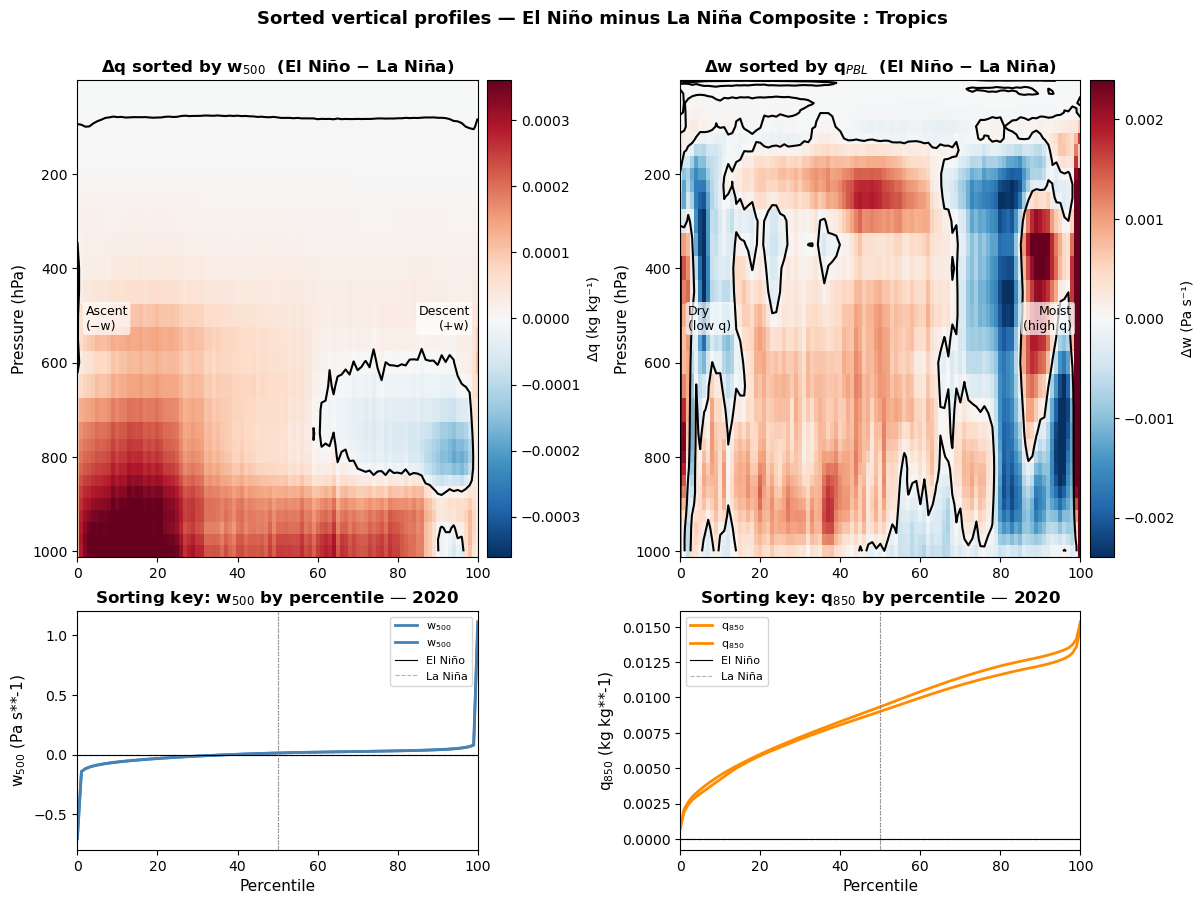

In [30]:
plot_4panel_difference(
    q_sorted_elnino_tropics, q_sorted_lanina_tropics,
    w_sorted_elnino_tropics,  w_sorted_lanina_tropics,
    w_trop, w_trop,
    q_trop, q_trop,
    t2016, t2008,
    suptitle="Sorted vertical profiles — El Niño minus La Niña Composite : Tropics",
    savepath="4panel_difference_ElNino_minus_LaNina_composite_tropics.png",
)

# OLD10 vs NEW10
### 1941-1950 vs 2011-2020

In [31]:
#OLD

In [32]:
OldYrs = [1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950]

# Build a boolean mask selecting all months in Old years
old_mask = w.time.dt.year.isin(OldYrs).compute()
old_times = w.time.isel(time=old_mask)
print(f"OLD months: {int(old_mask.sum())} "
      f"({OldYrs[0]}–{OldYrs[-1]})")

# Sort q profiles by w500 — Old composite, tropics
q_sorted_old_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = q,
    base_level = 500,
    time_slice = old_mask,        # ← pass the boolean mask directly
    lat_bounds = (-30, 30),
    output_file= "q_sorted_by_w500_old_tropics.nc",
)

# Sort w profiles by lower-tropospheric q — Old composite, tropics
w_sorted_old_tropics = sort_profiles_by_level(
    da_base    = q,
    da_target  = w,
    base_level = [800., 825., 850., 875., 900., 925., 950., 975., 1000.],
    time_slice = old_mask,
    lat_bounds = (-30, 30),
    output_file= "w_sorted_by_qLT_old_tropics.nc",
)

OLD months: 120 (1941–1950)
File exists, loading: q_sorted_by_w500_old_tropics.nc
File exists, loading: w_sorted_by_qLT_old_tropics.nc


In [33]:
# New

In [34]:
NewYrs = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

# Build a boolean mask selecting all months in New years
new_mask = w.time.dt.year.isin(NewYrs).compute()
new_times = w.time.isel(time=new_mask)
print(f"NEW months: {int(new_mask.sum())} "
      f"({NewYrs[0]}–{NewYrs[-1]})")

# Sort q profiles by w500 — New composite, tropics
q_sorted_new_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = q,
    base_level = 500,
    time_slice = new_mask,        # ← pass the boolean mask directly
    lat_bounds = (-30, 30),
    output_file= "q_sorted_by_w500_new_tropics.nc",
)

# Sort w profiles by lower-tropospheric q — New composite, tropics
w_sorted_new_tropics = sort_profiles_by_level(
    da_base    = q,
    da_target  = w,
    base_level = [800., 825., 850., 875., 900., 925., 950., 975., 1000.],
    time_slice = new_mask,
    lat_bounds = (-30, 30),
    output_file= "w_sorted_by_qLT_new_tropics.nc",
)

NEW months: 120 (2011–2020)
File exists, loading: q_sorted_by_w500_new_tropics.nc
File exists, loading: w_sorted_by_qLT_new_tropics.nc


Percentile of 
Percentile of 


/tmp/ipykernel_2004/823573116.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


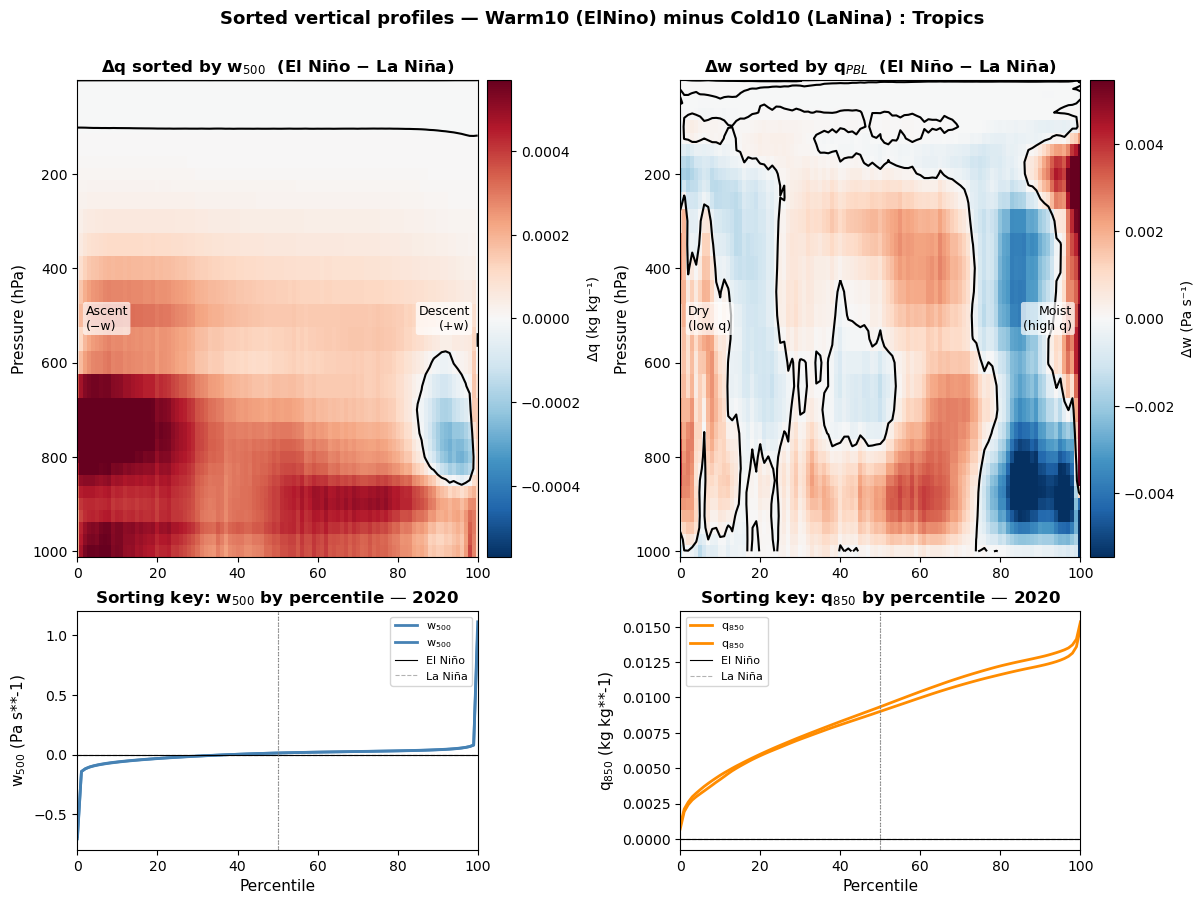

In [35]:
plot_4panel_difference(
    q_sorted_new_tropics, q_sorted_old_tropics,
    w_sorted_new_tropics,  w_sorted_old_tropics,
    w_trop, w_trop,
    q_trop, q_trop,
    t2016, t2008,
    suptitle="Sorted vertical profiles — Warm10 (ElNino) minus Cold10 (LaNina) : Tropics",
    savepath="4panel_difference_warm_minus_cold_composite_tropics.png",
)

In [36]:
# Sort w profiles by w500 — New composite, tropics

# WARMER = NEW = El Nino
# COLDER = OLD = La Nina

#New
ww_sorted_new_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = w,
    base_level = 500,
    time_slice = new_mask,
    lat_bounds = (-30, 30),
    output_file= "ww_sorted_by_w500_new_tropics.nc",
)

#El Nino
ww_sorted_elnino_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = w,
    base_level = 500,
    time_slice = elnino_mask,
    lat_bounds = (-30, 30),
    output_file= "ww_sorted_by_w500_elnino_tropics.nc",
)

#Old
ww_sorted_old_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = w,
    base_level = 500,
    time_slice = old_mask,
    lat_bounds = (-30, 30),
    output_file= "ww_sorted_by_w500_old_tropics.nc",
)

#La Nina
ww_sorted_lanina_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = w,
    base_level = 500,
    time_slice = lanina_mask,
    lat_bounds = (-30, 30),
    output_file= "ww_sorted_by_w500_lanina_tropics.nc",
)

File exists, loading: ww_sorted_by_w500_new_tropics.nc
File exists, loading: ww_sorted_by_w500_elnino_tropics.nc
File exists, loading: ww_sorted_by_w500_old_tropics.nc
File exists, loading: ww_sorted_by_w500_lanina_tropics.nc


/tmp/ipykernel_2004/3692268127.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


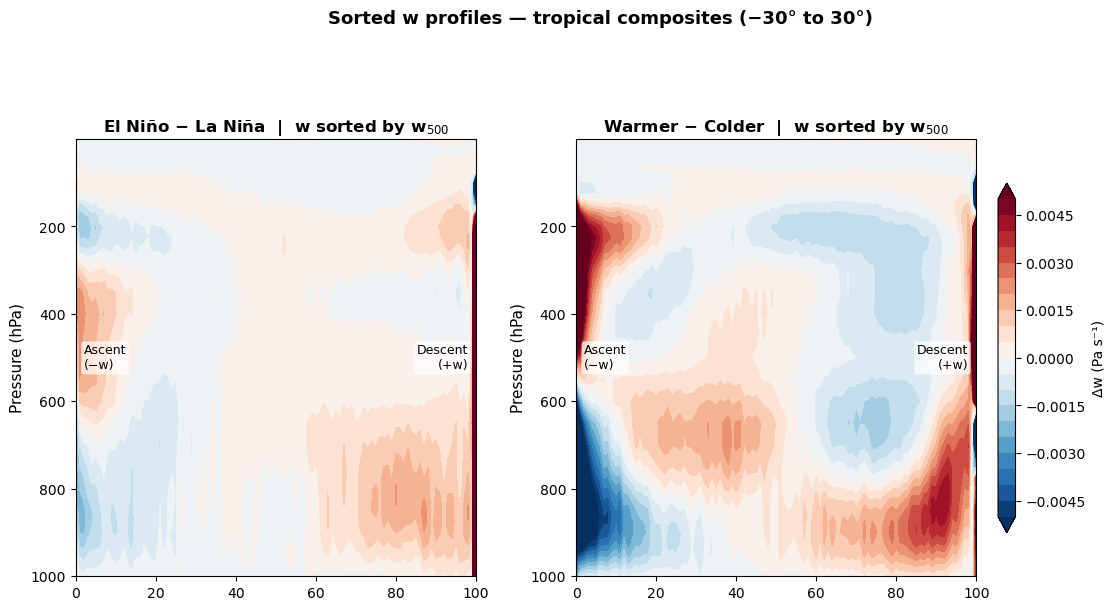

In [37]:
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[2, 1],
    hspace=0.35,
    wspace=0.25,
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    # [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ── compute differences (time-mean first, then diff) ─────────────────────────
diff_enso   = ww_sorted_elnino_tropics.mean("time") - ww_sorted_lanina_tropics.mean("time")
diff_warmcold = ww_sorted_new_tropics.mean("time")  - ww_sorted_old_tropics.mean("time")

# ── symmetric colorbar limit across both panels ───────────────────────────────
vmax = np.nanpercentile(
    np.abs(np.stack([diff_enso.values, diff_warmcold.values])), 98
)
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

# ── helper ────────────────────────────────────────────────────────────────────
def plot_diff_pcolormesh(da_diff, ax, title):
    levels = da_diff.level.values
    pcts   = da_diff.percentile.values
    pcm = ax.pcolormesh(pcts, levels, da_diff.values,
                        cmap="RdBu_r", norm=norm, shading="auto")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.tick_params(labelbottom=True)
    # ascent/descent annotations
    ax_kw = dict(transform=ax.transAxes, fontsize=9, va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.5, "Ascent\n(−w)", ha="left",  **ax_kw)
    ax.text(0.98, 0.5, "Descent\n(+w)", ha="right", **ax_kw)
    return pcm

def plot_diff_contourf(da_diff, ax, title):
    pcts   = da_diff.percentile.values
    press  = da_diff.level.values
    clevels = np.linspace(-0.005, 0.005, 21)

    pcm = ax.contourf(pcts, press, da_diff.values,
                      levels=clevels,
                      cmap="RdBu_r",
                      extend="both")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.tick_params(labelbottom=True)
    ax_kw = dict(transform=ax.transAxes, fontsize=9, va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.5, "Ascent\n(−w)", ha="left",  **ax_kw)
    ax.text(0.98, 0.5, "Descent\n(+w)", ha="right", **ax_kw)
    return pcm

# ── row 0: difference panels ──────────────────────────────────────────────────
pcm1 = plot_diff_contourf(diff_enso,     axes[0, 0], "El Niño − La Niña  |  w sorted by w$_{500}$")
pcm2 = plot_diff_contourf(diff_warmcold, axes[0, 1], "Warmer − Colder  |  w sorted by w$_{500}$")

# shared colorbar
cbar = fig.colorbar(pcm1, ax=axes[0, :].tolist(), 
                    label="Δw (Pa s⁻¹)", pad=0.02, shrink=0.8)

# # ── row 1: reference profiles for context ────────────────────────────────────
# def plot_ref_lines(ax, da_list, labels, colors, title):
#     """Plot time-mean w at a fixed level (500 hPa) across percentiles."""
#     for da, label, color in zip(da_list, labels, colors):
#         mean_w500 = da.sel(level=500, method="nearest").mean("time")
#         ax.plot(da.percentile.values, mean_w500.values,
#                 label=label, color=color, lw=1.8)
#     ax.axhline(0, color="k", lw=0.8, ls="--")
#     ax.axvline(50, color="grey", lw=0.8, ls=":")
#     ax.set_xlabel("Percentile of w$_{500}$", fontsize=11)
#     ax.set_ylabel("w$_{500}$ (Pa s⁻¹)", fontsize=11)
#     ax.set_title(title, fontsize=11, fontweight="bold")
#     ax.legend(fontsize=9)
#     ax.set_xlim(0, 99)

# plot_ref_lines(
#     axes[1, 0],
#     da_list = [ww_sorted_elnino_tropics, ww_sorted_lanina_tropics],
#     labels  = ["El Niño", "La Niña"],
#     colors  = ["tomato", "steelblue"],
#     title   = "w$_{500}$ by percentile — ENSO composites",
# )

# plot_ref_lines(
#     axes[1, 1],
#     da_list = [ww_sorted_new_tropics, ww_sorted_old_tropics],
#     labels  = ["Warmer", "Colder"],
#     colors  = ["tomato", "steelblue"],
#     title   = "w$_{500}$ by percentile — Warmer/Colder composites",
# )

# ── align panel widths (colorbar shifts top panels) ──────────────────────────
for col in range(2):
    axes[0, col].set_xlim(0, 100)
    # axes[1, col].set_xlim(0, 100)

plt.tight_layout()

for col in range(2):
    pos_top = axes[0, col].get_position()
    pos_bot = axes[0, col].get_position()
    axes[0, col].set_position([
        pos_top.x0, pos_bot.y0, pos_top.width, pos_bot.height
    ])

plt.suptitle("Sorted w profiles — tropical composites (−30° to 30°)",
             fontsize=13, fontweight="bold", y=1.01)

plt.savefig("ww_sorted_differences_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

# Rob suggested that the circulation response might be due to different phases of PDO. So check changing the periods to different decades and also checking changing the duration and 

In [38]:
# Sort w profiles by w500 — New composite, tropics

# WARMER = NEW = El Nino
# COLDER = OLD = La Nina

#New
ww_sorted_new_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = w,
    base_level = 500,
    time_slice = new_mask,
    lat_bounds = (-30, 30),
    output_file= "ww_sorted_by_w500_new_tropics.nc",
)

#Old
ww_sorted_old_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = w,
    base_level = 500,
    time_slice = old_mask,
    lat_bounds = (-30, 30),
    output_file= "ww_sorted_by_w500_old_tropics.nc",
)

#Old1
OldYrs1 = [1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980]

# Build a boolean mask selecting all months in Old years
old_mask1 = w.time.dt.year.isin(OldYrs1).compute()
old_times1 = w.time.isel(time=old_mask1)
print(f"OLD months: {int(old_mask1.sum())} "
      f"({OldYrs1[0]}–{OldYrs1[-1]})")

#Old
ww_sorted_old1_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = w,
    base_level = 500,
    time_slice = old_mask1,
    lat_bounds = (-30, 30),
    output_file= "ww_sorted_by_w500_old1_tropics.nc",
)

File exists, loading: ww_sorted_by_w500_new_tropics.nc
File exists, loading: ww_sorted_by_w500_old_tropics.nc
OLD months: 120 (1971–1980)
File exists, loading: ww_sorted_by_w500_old1_tropics.nc


/tmp/ipykernel_2004/412919380.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


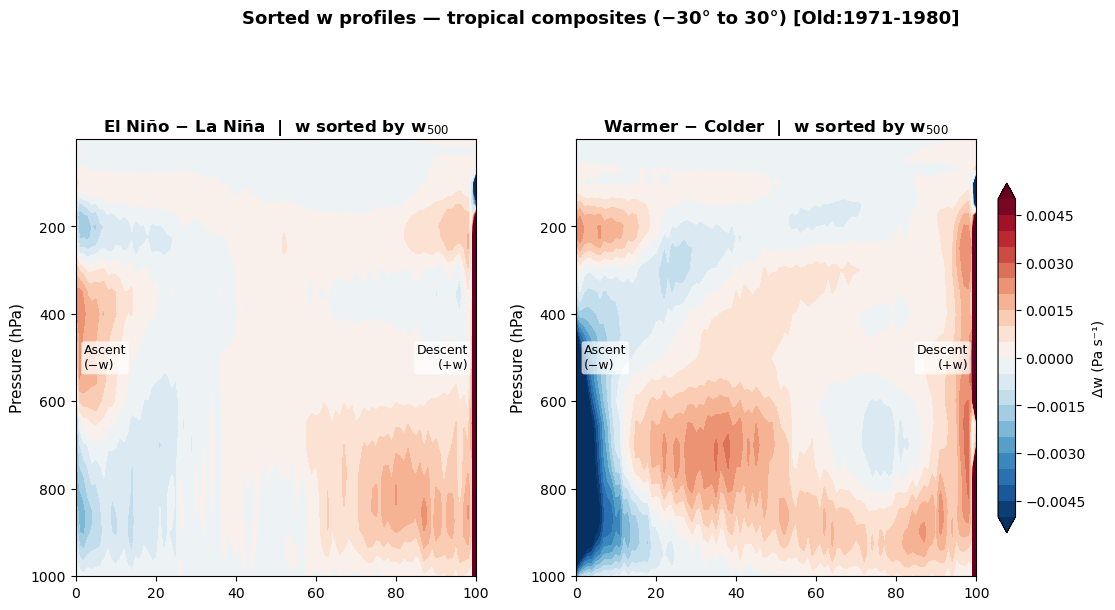

In [39]:
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[2, 1],
    hspace=0.35,
    wspace=0.25,
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    # [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ── compute differences (time-mean first, then diff) ─────────────────────────
diff_enso   = ww_sorted_elnino_tropics.mean("time") - ww_sorted_lanina_tropics.mean("time")
diff_warmcold = ww_sorted_new_tropics.mean("time")  - ww_sorted_old1_tropics.mean("time")

# ── symmetric colorbar limit across both panels ───────────────────────────────
vmax = np.nanpercentile(
    np.abs(np.stack([diff_enso.values, diff_warmcold.values])), 98
)
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

# ── helper ────────────────────────────────────────────────────────────────────
def plot_diff_pcolormesh(da_diff, ax, title):
    levels = da_diff.level.values
    pcts   = da_diff.percentile.values
    pcm = ax.pcolormesh(pcts, levels, da_diff.values,
                        cmap="RdBu_r", norm=norm, shading="auto")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.tick_params(labelbottom=True)
    # ascent/descent annotations
    ax_kw = dict(transform=ax.transAxes, fontsize=9, va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.5, "Ascent\n(−w)", ha="left",  **ax_kw)
    ax.text(0.98, 0.5, "Descent\n(+w)", ha="right", **ax_kw)
    return pcm

def plot_diff_contourf(da_diff, ax, title):
    pcts   = da_diff.percentile.values
    press  = da_diff.level.values
    clevels = np.linspace(-0.005, 0.005, 21)

    pcm = ax.contourf(pcts, press, da_diff.values,
                      levels=clevels,
                      cmap="RdBu_r",
                      extend="both")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.tick_params(labelbottom=True)
    ax_kw = dict(transform=ax.transAxes, fontsize=9, va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.5, "Ascent\n(−w)", ha="left",  **ax_kw)
    ax.text(0.98, 0.5, "Descent\n(+w)", ha="right", **ax_kw)
    return pcm

# ── row 0: difference panels ──────────────────────────────────────────────────
pcm1 = plot_diff_contourf(diff_enso,     axes[0, 0], "El Niño − La Niña  |  w sorted by w$_{500}$")
pcm2 = plot_diff_contourf(diff_warmcold, axes[0, 1], "Warmer − Colder  |  w sorted by w$_{500}$")

# shared colorbar
cbar = fig.colorbar(pcm1, ax=axes[0, :].tolist(), 
                    label="Δw (Pa s⁻¹)", pad=0.02, shrink=0.8)

# ── align panel widths (colorbar shifts top panels) ──────────────────────────
for col in range(2):
    axes[0, col].set_xlim(0, 100)
    # axes[1, col].set_xlim(0, 100)

plt.tight_layout()

for col in range(2):
    pos_top = axes[0, col].get_position()
    pos_bot = axes[0, col].get_position()
    axes[0, col].set_position([
        pos_top.x0, pos_bot.y0, pos_top.width, pos_bot.height
    ])

plt.suptitle("Sorted w profiles — tropical composites (−30° to 30°) [Old:1971-1980]",
             fontsize=13, fontweight="bold", y=1.01)

plt.savefig("ww_sorted_differences_tropics_periods1.png", dpi=150, bbox_inches="tight")
plt.show()

# Longer new and old

In [40]:
# Sort w profiles by w500 — New composite, tropics

# WARMER = NEW = El Nino
# COLDER = OLD = La Nina

# ── Old period: 1941–1970 ─────────────────────────────────────────────────────
OldYrsLong = list(range(1941, 1971))   # 1941, 1942, ..., 1970

old_mask_long  = w.time.dt.year.isin(OldYrsLong).compute()
print(f"OLD months:  {int(old_mask_long.sum())} "
      f"({OldYrsLong[0]}–{OldYrsLong[-1]})")

ww_sorted_old_long_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = w,
    base_level = 500,
    time_slice = old_mask_long,
    lat_bounds = (-30, 30),
    output_file= "ww_sorted_by_w500_old_long_tropics.nc",
)

# ── New period: 1991–2020 ─────────────────────────────────────────────────────
NewYrsLong = list(range(1991, 2021))   # 1991, 1992, ..., 2020

new_mask_long  = w.time.dt.year.isin(NewYrsLong).compute()
print(f"NEW months:  {int(new_mask_long.sum())} "
      f"({NewYrsLong[0]}–{NewYrsLong[-1]})")

ww_sorted_new_long_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = w,
    base_level = 500,
    time_slice = new_mask_long,
    lat_bounds = (-30, 30),
    output_file= "ww_sorted_by_w500_new_long_tropics.nc",
)



OLD months:  360 (1941–1970)
File exists, loading: ww_sorted_by_w500_old_long_tropics.nc
NEW months:  360 (1991–2020)
  Cropped to lat [-30, 30]: 98816 / 196608 cells retained
Saving → ww_sorted_by_w500_new_long_tropics.nc


/tmp/ipykernel_2004/1799492629.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


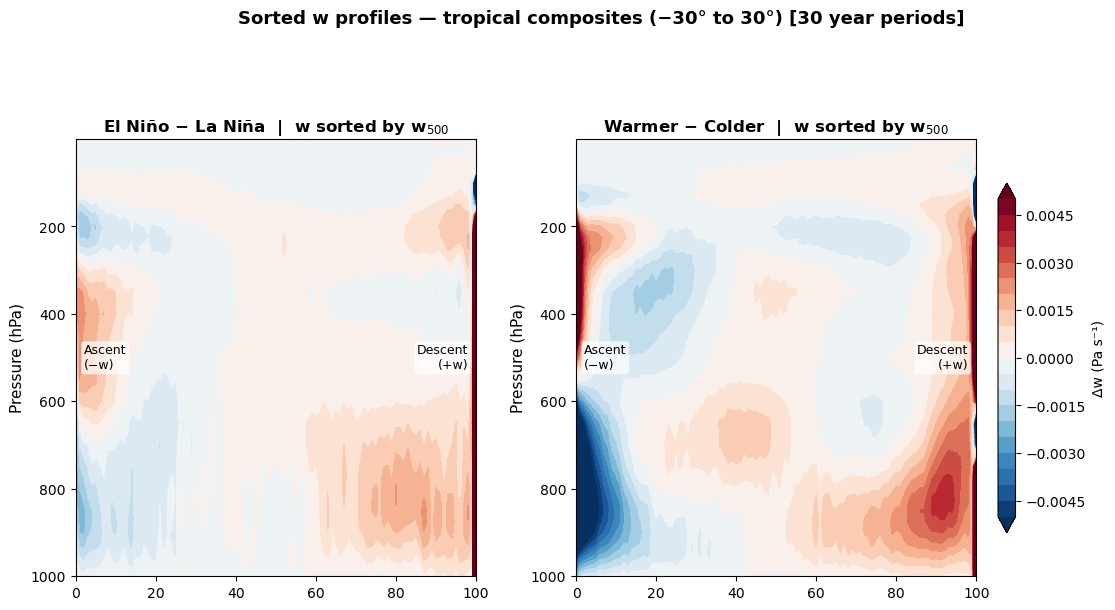

In [41]:
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[2, 1],
    hspace=0.35,
    wspace=0.25,
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    # [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ── compute differences (time-mean first, then diff) ─────────────────────────
diff_enso   = ww_sorted_elnino_tropics.mean("time") - ww_sorted_lanina_tropics.mean("time")
diff_warmcold = ww_sorted_new_long_tropics.mean("time")  - ww_sorted_old_long_tropics.mean("time")

# ── symmetric colorbar limit across both panels ───────────────────────────────
vmax = np.nanpercentile(
    np.abs(np.stack([diff_enso.values, diff_warmcold.values])), 98
)
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

# ── helper ────────────────────────────────────────────────────────────────────
def plot_diff_pcolormesh(da_diff, ax, title):
    levels = da_diff.level.values
    pcts   = da_diff.percentile.values
    pcm = ax.pcolormesh(pcts, levels, da_diff.values,
                        cmap="RdBu_r", norm=norm, shading="auto")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.tick_params(labelbottom=True)
    # ascent/descent annotations
    ax_kw = dict(transform=ax.transAxes, fontsize=9, va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.5, "Ascent\n(−w)", ha="left",  **ax_kw)
    ax.text(0.98, 0.5, "Descent\n(+w)", ha="right", **ax_kw)
    return pcm

def plot_diff_contourf(da_diff, ax, title):
    pcts   = da_diff.percentile.values
    press  = da_diff.level.values
    clevels = np.linspace(-0.005, 0.005, 21)

    pcm = ax.contourf(pcts, press, da_diff.values,
                      levels=clevels,
                      cmap="RdBu_r",
                      extend="both")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.tick_params(labelbottom=True)
    ax_kw = dict(transform=ax.transAxes, fontsize=9, va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.5, "Ascent\n(−w)", ha="left",  **ax_kw)
    ax.text(0.98, 0.5, "Descent\n(+w)", ha="right", **ax_kw)
    return pcm

# ── row 0: difference panels ──────────────────────────────────────────────────
pcm1 = plot_diff_contourf(diff_enso,     axes[0, 0], "El Niño − La Niña  |  w sorted by w$_{500}$")
pcm2 = plot_diff_contourf(diff_warmcold, axes[0, 1], "Warmer − Colder  |  w sorted by w$_{500}$")

# shared colorbar
cbar = fig.colorbar(pcm1, ax=axes[0, :].tolist(), 
                    label="Δw (Pa s⁻¹)", pad=0.02, shrink=0.8)

# ── align panel widths (colorbar shifts top panels) ──────────────────────────
for col in range(2):
    axes[0, col].set_xlim(0, 100)
    # axes[1, col].set_xlim(0, 100)

plt.tight_layout()

for col in range(2):
    pos_top = axes[0, col].get_position()
    pos_bot = axes[0, col].get_position()
    axes[0, col].set_position([
        pos_top.x0, pos_bot.y0, pos_top.width, pos_bot.height
    ])

plt.suptitle("Sorted w profiles — tropical composites (−30° to 30°) [30 year periods]",
             fontsize=13, fontweight="bold", y=1.01)

plt.savefig("ww_sorted_differences_tropics_LongPeriods.png", dpi=150, bbox_inches="tight")
plt.show()

# MSE contrast analysis

### I am seeing a restructuring of vertical structure. Does it mean more detrainment in the middle troposphere? Does it mean more congestus? Is it because of larger or smaller contrast between cloudy and dry regions in the atmosphere? To check it, I am plotting MSE contrast between 0-10% and 10-90% for warmer and colder climate.

In [42]:
# ── compute MSE ───────────────────────────────────────────────────────────────
# h = Cp*T + z + Lv*q
# Cp = 1005 J kg-1 K-1 (dry air)
# Lv = 2.5e6 J kg-1 (latent heat of vaporisation)
# z is already geopotential (m2 s-2), so gz term is just z

# t=ds.t #Temperature units :K
# z=ds.z #Geopotential units :m**2 s**-2

Cp = 1005.0    # J kg-1 K-1
Lv = 2.501e6   # J kg-1

mse = Cp * ds.t + ds.z + Lv * ds.q   # units: J kg-1
mse.name = "mse"
mse.attrs = {
    "long_name": "Moist Static Energy",
    "units":     "J kg-1",
    "formula":   "Cp*T + z + Lv*q",
}

In [43]:
# ── sort MSE profiles by w500 — four composites, tropics ─────────────────────
mse_sorted_new_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = mse,
    base_level = 500,
    time_slice = new_mask,
    lat_bounds = (-30, 30),
    output_file= "mse_sorted_by_w500_new_tropics.nc",
)

mse_sorted_elnino_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = mse,
    base_level = 500,
    time_slice = elnino_mask,
    lat_bounds = (-30, 30),
    output_file= "mse_sorted_by_w500_elnino_tropics.nc",
)

mse_sorted_old_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = mse,
    base_level = 500,
    time_slice = old_mask,
    lat_bounds = (-30, 30),
    output_file= "mse_sorted_by_w500_old_tropics.nc",
)

mse_sorted_lanina_tropics = sort_profiles_by_level(
    da_base    = w,
    da_target  = mse,
    base_level = 500,
    time_slice = lanina_mask,
    lat_bounds = (-30, 30),
    output_file= "mse_sorted_by_w500_lanina_tropics.nc",
)

File exists, loading: mse_sorted_by_w500_new_tropics.nc
File exists, loading: mse_sorted_by_w500_elnino_tropics.nc
File exists, loading: mse_sorted_by_w500_old_tropics.nc
File exists, loading: mse_sorted_by_w500_lanina_tropics.nc


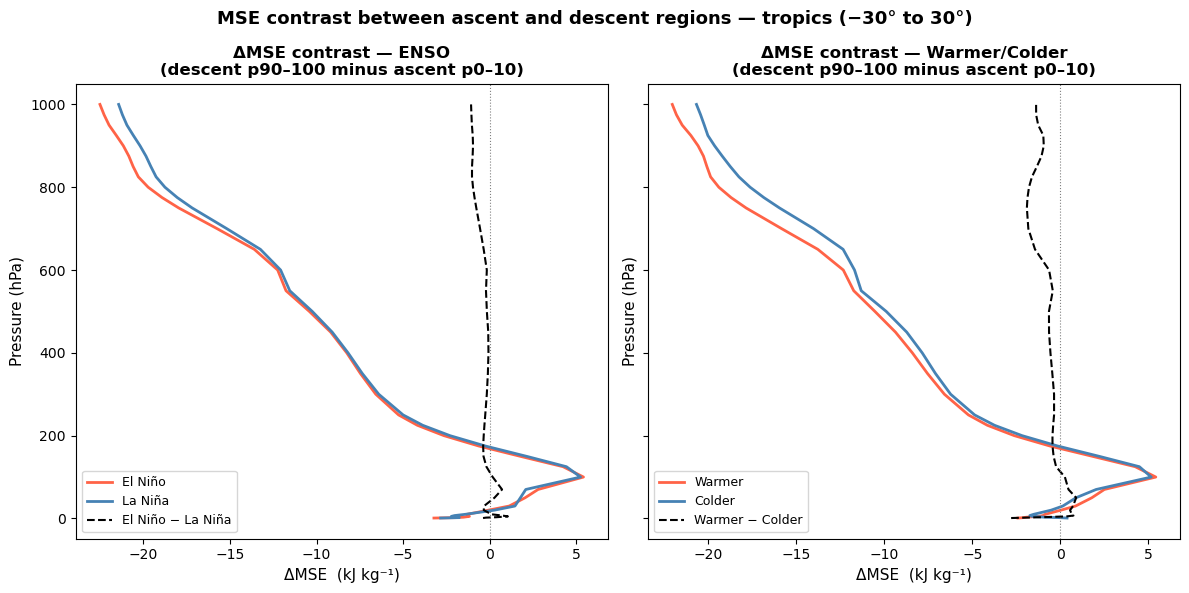

In [44]:
def mse_contrast(da_sorted):
    """
    ΔMSE = <h>_p90-100 − <h>_p10-90
    Ascent region   : percentile  0–10  (most negative w = strongest ascent)
    Descent region  : percentile 90–100 (most positive w = strongest descent)
    Middle          : percentile 10–90
    Returns a DataArray of shape (level,)
    """
    h = da_sorted.mean("time")   # (level, percentile)
    ascent  = h.sel(percentile=slice(0,  10)).mean("percentile")
    descent = h.sel(percentile=slice(90, 100)).mean("percentile")
    return descent - ascent      # shape (level,)


# ── compute contrasts ─────────────────────────────────────────────────────────
contrast_elnino  = mse_contrast(mse_sorted_elnino_tropics)
contrast_lanina  = mse_contrast(mse_sorted_lanina_tropics)
contrast_new     = mse_contrast(mse_sorted_new_tropics)
contrast_old     = mse_contrast(mse_sorted_old_tropics)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

def plot_contrast_pair(ax, da1, da2, label1, label2, color1, color2, title):
    levels = da1.level.values
    ax.plot(da1.values / 1e3, levels, color=color1, lw=2,   label=label1)
    ax.plot(da2.values / 1e3, levels, color=color2, lw=2,   label=label2)
    ax.plot((da1 - da2).values / 1e3, levels,
            color="k", lw=1.5, ls="--", label=f"{label1} − {label2}")
    ax.axvline(0, color="grey", lw=0.8, ls=":")
    ax.invert_yaxis()
    ax.set_xlabel("ΔMSE  (kJ kg⁻¹)", fontsize=11)
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

plot_contrast_pair(
    axes[0],
    contrast_elnino, contrast_lanina,
    "El Niño", "La Niña",
    "tomato", "steelblue",
    "ΔMSE contrast — ENSO\n(descent p90–100 minus ascent p0–10)",
)

plot_contrast_pair(
    axes[1],
    contrast_new, contrast_old,
    "Warmer", "Colder",
    "tomato", "steelblue",
    "ΔMSE contrast — Warmer/Colder\n(descent p90–100 minus ascent p0–10)",
)

plt.suptitle("MSE contrast between ascent and descent regions — tropics (−30° to 30°)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mse_contrast_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

Percentile of w$_{500}$ (Pa s⁻¹)
Percentile of w$_{500}$ (Pa s⁻¹)
Percentile of w$_{500}$ (Pa s⁻¹)
Percentile of w$_{500}$ (Pa s⁻¹)


/tmp/ipykernel_2004/1091727314.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


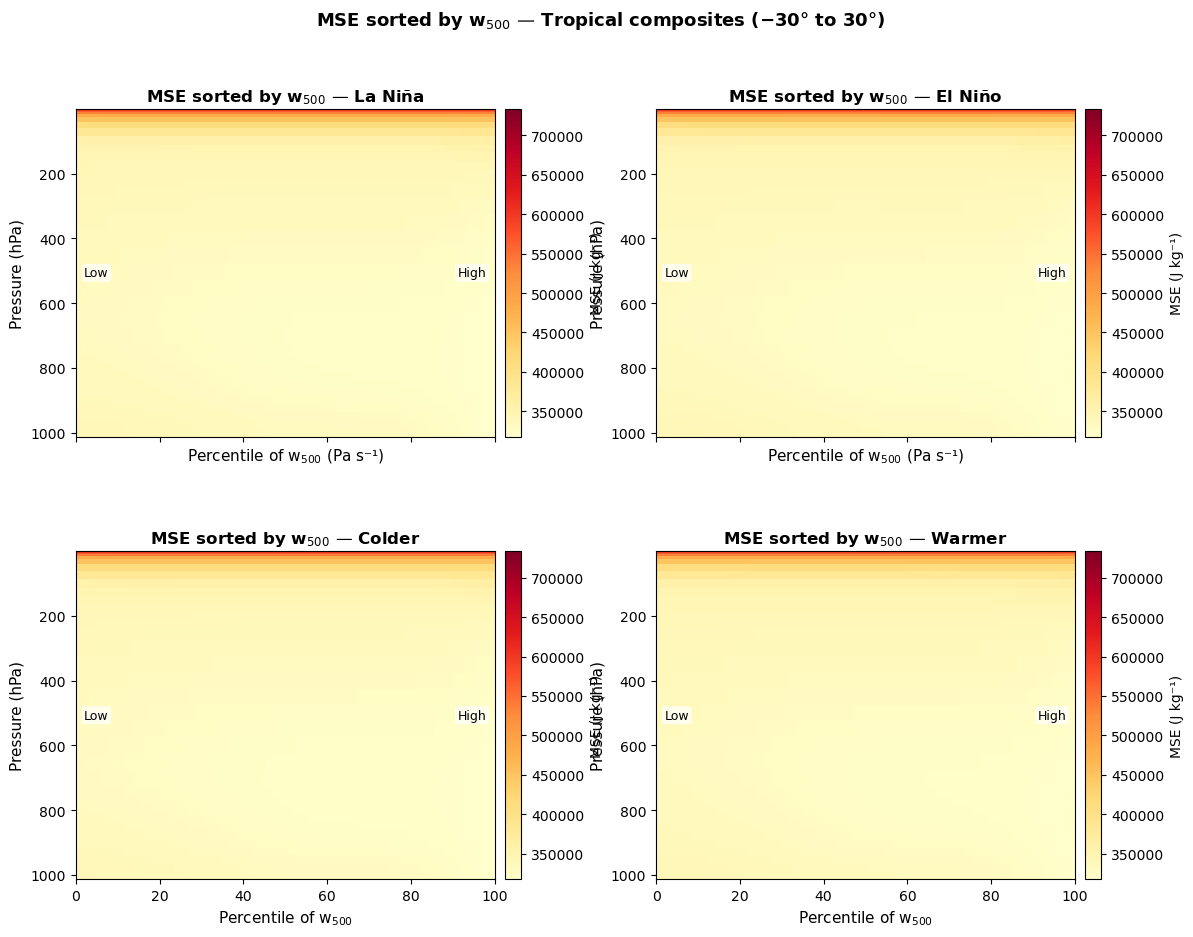

In [45]:
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1],
    hspace=0.35,
    wspace=0.15,
)
axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ── compute a shared vmin/vmax across all four panels ────────────────────────
all_data = np.concatenate([
    mse_sorted_lanina_tropics.mean("time").values.ravel(),
    mse_sorted_elnino_tropics.mean("time").values.ravel(),
    mse_sorted_old_tropics.mean("time").values.ravel(),
    mse_sorted_new_tropics.mean("time").values.ravel(),
])
vmin = np.nanpercentile(all_data, 2)
vmax = np.nanpercentile(all_data, 98)

# ── row 0: ENSO ───────────────────────────────────────────────────────────────
pcm1 = plot_sorted_profiles(
    mse_sorted_lanina_tropics, axes[0, 0],
    title="MSE sorted by w$_{500}$ — La Niña",
    xlabel="", cmap="YlOrRd", vmin=vmin, vmax=vmax,
)
fig.colorbar(pcm1, ax=axes[0, 0], label="MSE (J kg⁻¹)", pad=0.02)

pcm2 = plot_sorted_profiles(
    mse_sorted_elnino_tropics, axes[0, 1],
    title="MSE sorted by w$_{500}$ — El Niño",
    xlabel="", cmap="YlOrRd", vmin=vmin, vmax=vmax,
)
fig.colorbar(pcm2, ax=axes[0, 1], label="MSE (J kg⁻¹)", pad=0.02)

# ── row 1: warm/cold ──────────────────────────────────────────────────────────
pcm3 = plot_sorted_profiles(
    mse_sorted_old_tropics, axes[1, 0],
    title="MSE sorted by w$_{500}$ — Colder",
    xlabel="", cmap="YlOrRd", vmin=vmin, vmax=vmax,
)
fig.colorbar(pcm3, ax=axes[1, 0], label="MSE (J kg⁻¹)", pad=0.02)

pcm4 = plot_sorted_profiles(
    mse_sorted_new_tropics, axes[1, 1],
    title="MSE sorted by w$_{500}$ — Warmer",
    xlabel="", cmap="YlOrRd", vmin=vmin, vmax=vmax,
)
fig.colorbar(pcm4, ax=axes[1, 1], label="MSE (J kg⁻¹)", pad=0.02)

# ── shared x label on bottom row only ────────────────────────────────────────
for ax in axes[0]:
    ax.tick_params(labelbottom=False)
for ax in axes[1]:
    ax.set_xlabel("Percentile of w$_{500}$", fontsize=11)

# ── enforce identical x limits ────────────────────────────────────────────────
for ax in axes.ravel():
    ax.set_xlim(0, 100)

plt.suptitle("MSE sorted by w$_{500}$ — Tropical composites (−30° to 30°)",
             fontsize=13, fontweight="bold")
plt.tight_layout()

# ── align panel widths after tight_layout (colorbars shift axes) ──────────────
for col in range(2):
    pos_top = axes[0, col].get_position()
    pos_bot = axes[1, col].get_position()
    axes[1, col].set_position([
        pos_top.x0, pos_bot.y0, pos_top.width, pos_bot.height
    ])

plt.savefig("4panel_mse_sorted_composites_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_2004/208864635.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


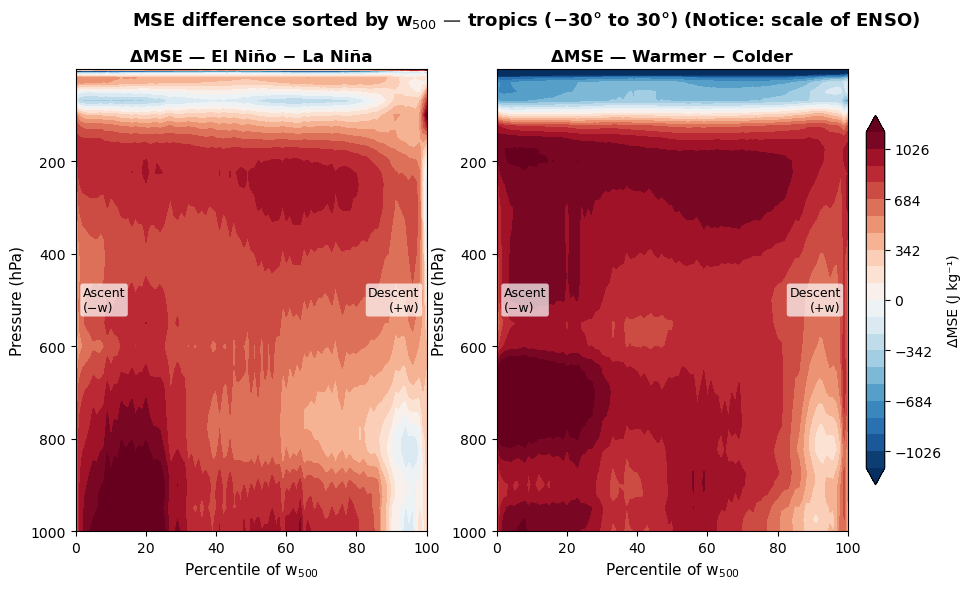

In [46]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, wspace=0.2)
axes = np.array([fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])])

# ── compute differences ───────────────────────────────────────────────────────
diff_enso     = mse_sorted_elnino_tropics.mean("time") - mse_sorted_lanina_tropics.mean("time")
diff_warmcold = mse_sorted_new_tropics.mean("time")    - mse_sorted_old_tropics.mean("time")

# ── shared symmetric contour levels ──────────────────────────────────────────
vmax = np.nanpercentile(
    np.abs(np.stack([diff_enso.values, diff_warmcold.values])), 90
)
clevels = np.linspace(-vmax, vmax, 21)
clevels1 = np.linspace(-vmax/2, vmax/2, 21)

# ── plot ──────────────────────────────────────────────────────────────────────
def plot_mse_diff(da_diff, ax, title, cl):
    pcts  = da_diff.percentile.values
    press = da_diff.level.values
    pcm = ax.contourf(pcts, press, da_diff.values,
                      levels=cl, cmap="RdBu_r", extend="both")
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentile of w$_{500}$", fontsize=11)
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax_kw = dict(transform=ax.transAxes, fontsize=9, va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.5, "Ascent\n(−w)", ha="left",  **ax_kw)
    ax.text(0.98, 0.5, "Descent\n(+w)", ha="right", **ax_kw)
    return pcm

pcm1 = plot_mse_diff(diff_enso,     axes[0], "ΔMSE — El Niño − La Niña",clevels1)
pcm2 = plot_mse_diff(diff_warmcold, axes[1], "ΔMSE — Warmer − Colder",clevels)

# ── shared colorbar ───────────────────────────────────────────────────────────
fig.colorbar(pcm1, ax=axes.tolist(), label="ΔMSE (J kg⁻¹)", pad=0.02, shrink=0.8)

plt.suptitle("MSE difference sorted by w$_{500}$ — tropics (−30° to 30°) (Notice: scale of ENSO)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mse_diff_sorted_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

# GMS

In [47]:
# ── Partial GMS using omega (Back & Bretherton 2006 approach) ─────────────────
# 
# Standard definition:
#   PGMS(p*) = ∫[p*→ptop] w * (∂h/∂p) dp  /  ∫[p*→ptop] w * (∂f/∂p) dp
#
# But the most tractable form with sorted profiles:
#   PGMS(p*) = -∫[ptop→p*] <w·h> dp  /  -∫[ptop→p*] <w> dp
#
# where the integral runs from TOA downward to level p*
# Negative signs because omega is positive downward
#
# We need joint wh — so we sort wh profiles by w500
# (cannot derive this from separately sorted w and h)

# ── Step 1: compute w*h at each level and cell ────────────────────────────────
wh = ds.w * mse      # (time, level, cell) units: Pa s-1 * J kg-1
wh.name = "wh"
wh.attrs = {
    "long_name": "Vertical MSE flux (omega * MSE)",
    "units":     "Pa s-1 J kg-1",
}

In [48]:
# ── Step 2: sort wh and w profiles by w500 — same four composites ─────────────
# We need BOTH wh and w sorted by the SAME w500 key so they share percentile bins

wh_sorted_elnino_tropics = sort_profiles_by_level(
    da_base    = ds.w,
    da_target  = wh,
    base_level = 500,
    time_slice = elnino_mask,
    lat_bounds = (-30, 30),
    output_file= "wh_sorted_by_w500_elnino_tropics.nc",
)

wh_sorted_lanina_tropics = sort_profiles_by_level(
    da_base    = ds.w,
    da_target  = wh,
    base_level = 500,
    time_slice = lanina_mask,
    lat_bounds = (-30, 30),
    output_file= "wh_sorted_by_w500_lanina_tropics.nc",
)

wh_sorted_new_tropics = sort_profiles_by_level(
    da_base    = ds.w,
    da_target  = wh,
    base_level = 500,
    time_slice = new_mask,
    lat_bounds = (-30, 30),
    output_file= "wh_sorted_by_w500_new_tropics.nc",
)

wh_sorted_old_tropics = sort_profiles_by_level(
    da_base    = ds.w,
    da_target  = wh,
    base_level = 500,
    time_slice = old_mask,
    lat_bounds = (-30, 30),
    output_file= "wh_sorted_by_w500_old_tropics.nc",
)

# I already have ww_sorted_* (w sorted by w500) from before — reuse those

File exists, loading: wh_sorted_by_w500_elnino_tropics.nc
File exists, loading: wh_sorted_by_w500_lanina_tropics.nc
File exists, loading: wh_sorted_by_w500_new_tropics.nc
File exists, loading: wh_sorted_by_w500_old_tropics.nc


In [49]:

# ── Step 3: compute PGMS profile from sorted arrays ───────────────────────────
def compute_pgms(wh_sorted, ww_sorted, ascent_pct=slice(0, 10)):
    """
    Partial GMS profile for ascent region.

    PGMS(p*) = cumulative integral of <wh> from TOA to p*
             / cumulative integral of <w>  from TOA to p*

    Both integrals run top-down (TOA → surface) so we flip level order,
    integrate, then flip back.

    Parameters
    ----------
    wh_sorted : DataArray (time, level, percentile) — w*MSE sorted by w500
    ww_sorted : DataArray (time, level, percentile) — w sorted by w500
    ascent_pct: percentile slice selecting ascent columns

    Returns
    -------
    DataArray (level,) — PGMS profile in ascent region
    """
    # time-mean and select ascent percentiles
    wh = wh_sorted.mean("time").sel(percentile=ascent_pct).mean("percentile")  # (level,)
    ww = ww_sorted.mean("time").sel(percentile=ascent_pct).mean("percentile")  # (level,)

    # pressure in Pa for integration (level coord is in hPa)
    p_Pa = wh.level.values * 100.0   # hPa → Pa

    # flip to integrate top-down (TOA first)
    wh_vals = wh.values[::-1]
    ww_vals = ww.values[::-1]
    p_vals  = p_Pa[::-1]

    # cumulative trapezoid integral top → p*
    from scipy.integrate import cumulative_trapezoid
    cum_wh = cumulative_trapezoid(wh_vals, p_vals, initial=0)
    cum_ww = cumulative_trapezoid(ww_vals, p_vals, initial=0)

    # PGMS: avoid division by zero near TOA
    with np.errstate(invalid="ignore", divide="ignore"):
        pgms_vals = np.where(np.abs(cum_ww) > 1e-10,
                             cum_wh / cum_ww,
                             np.nan)

    # flip back to surface-up order
    pgms_vals = pgms_vals[::-1]

    pgms = xr.DataArray(
        pgms_vals,
        dims=["level"],
        coords={"level": wh.level.values},
        name="PGMS",
        attrs={
            "long_name": "Partial Gross Moist Stability (ascent region)",
            "units":     "J kg-1",
        },
    )
    return pgms

In [50]:
# ── Step 4: compute for all four composites ────────────────────────────────────
pgms_elnino = compute_pgms(wh_sorted_elnino_tropics, ww_sorted_elnino_tropics)
pgms_lanina = compute_pgms(wh_sorted_lanina_tropics, ww_sorted_lanina_tropics)
pgms_new    = compute_pgms(wh_sorted_new_tropics,    ww_sorted_new_tropics)
pgms_old    = compute_pgms(wh_sorted_old_tropics,    ww_sorted_old_tropics)

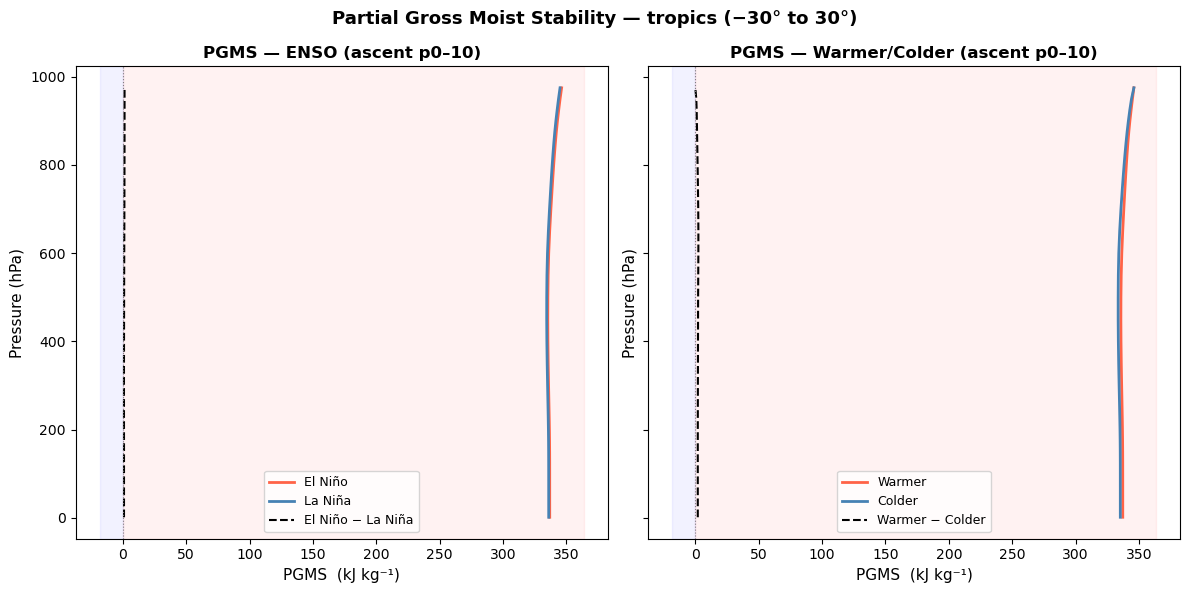

In [51]:
# ── Step 5: plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

def plot_pgms(ax, da1, da2, label1, label2, color1, color2, title):
    levels = da1.level.values
    ax.plot(da1.values / 1e3, levels, color=color1, lw=2,   label=label1)
    ax.plot(da2.values / 1e3, levels, color=color2, lw=2,   label=label2)
    ax.plot((da1 - da2).values / 1e3, levels,
            color="k", lw=1.5, ls="--", label=f"{label1} − {label2}")
    ax.axvline(0, color="grey", lw=0.8, ls=":")
    ax.invert_yaxis()
    ax.set_xlabel("PGMS  (kJ kg⁻¹)", fontsize=11)
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    # shade positive (stable) vs negative (unstable) regions
    ax.axvspan(0, ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 10,
               alpha=0.05, color="red",  label="_stable")
    ax.axvspan(ax.get_xlim()[0] if ax.get_xlim()[0] < 0 else -10, 0,
               alpha=0.05, color="blue", label="_unstable")

plot_pgms(
    axes[0],
    pgms_elnino, pgms_lanina,
    "El Niño", "La Niña", "tomato", "steelblue",
    "PGMS — ENSO (ascent p0–10)",
)
plot_pgms(
    axes[1],
    pgms_new, pgms_old,
    "Warmer", "Colder", "tomato", "steelblue",
    "PGMS — Warmer/Colder (ascent p0–10)",
)

plt.suptitle("Partial Gross Moist Stability — tropics (−30° to 30°)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pgms_profiles_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

In [52]:
pgms_old

<xarray.DataArray 'PGMS' (level: 37)> Size: 148B
array([335316.  , 335315.84, 335315.66, 335315.25, 335314.84, 335314.22,
       335312.56, 335311.44, 335310.16, 335308.25, 335304.44, 335294.4 ,
       335259.28, 335185.22, 335070.1 , 334919.28, 334742.72, 334368.9 ,
       334022.94, 333760.9 , 333620.5 , 333620.66, 333752.12, 334103.78,
       334810.1 , 335811.75, 336986.78, 337621.53, 338293.84, 339015.3 ,
       339799.62, 340673.72, 341673.06, 342814.84, 344152.  , 346030.84,
             nan], dtype=float32)
Coordinates:
  * level    (level) float32 148B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
Attributes:
    long_name:  Partial Gross Moist Stability (ascent region)
    units:      J kg-1

In [53]:
wh_sorted_old_tropics

<xarray.DataArray 'wh' (time: 120, level: 37, percentile: 101)> Size: 2MB
array([[[-2.102550e+01, -1.939463e+01, ...,  1.026814e+01,  7.784188e+00],
        [-2.395157e+01, -2.837237e+01, ..., -7.646414e+00,  4.377341e+00],
        ...,
        [-4.413062e+03, -4.781020e+03, ...,  8.760279e+03, -8.783916e+04],
        [-1.268749e+03, -1.916890e+03, ...,  9.015983e+03, -8.726232e+04]],

       [[-1.227154e+00, -1.311462e+01, ...,  3.997828e+00,  2.457827e+01],
        [-1.716570e+01, -2.567577e+01, ..., -1.097911e+01, -3.621486e+01],
        ...,
        [-6.778483e+03, -5.275569e+03, ...,  5.004729e+03,  1.925713e+04],
        [-3.158310e+03, -2.571067e+03, ...,  6.057164e+03,  1.935440e+04]],

       ...,

       [[-8.049726e+00, -1.028539e+01, ..., -1.424564e+00,  1.902752e+01],
        [-1.551214e+01, -2.304953e+01, ...,  1.922131e+01,  5.571163e+01],
        ...,
        [-3.491998e+03, -2.554475e+03, ...,  4.425885e+02, -1.850861e+04],
        [-2.131005e+02, -9.649274e+02, ...,  1.860997e+01, -1.848700e+04]],

       [[-2.182236e+01, -2.377309e+01, ...,  2.274555e+01,  3.436471e+01],
        [-4.461214e+01, -5.062193e+01, ...,  4.918254e+01,  7.226562e+01],
        ...,
        [-1.415161e+02, -3.722548e+03, ...,  2.639847e+03, -9.130827e+04],
        [ 2.174348e+03, -1.261429e+03, ...,  2.907822e+03, -9.032790e+04]]],
      shape=(120, 37, 101), dtype=float32)
Coordinates:
  * time        (time) datetime64[ns] 960B 1941-01-01 1941-02-01 ... 1950-12-01
  * level       (level) float32 148B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * percentile  (percentile) int64 808B 0 1 2 3 4 5 6 ... 94 95 96 97 98 99 100
Attributes:
    long_name:         Vertical MSE flux (omega * MSE)
    units:             Pa s-1 J kg-1
    sorting_variable:  w
    sorting_level:     500
    lat_bounds:        (-30, 30)

In [54]:
# def compute_pgms(wh_sorted, ww_sorted):
#     """
#     Compute PGMS for every (time, percentile) independently,
#     then return the time-mean giving shape (level, percentile).

#     PGMS(p*, pct) = ∫[TOA→p*] <wh>(p, pct) dp
#                   / ∫[TOA→p*] <ww>(p, pct) dp

#     Integral runs top-down (low pressure → high pressure).

#     Parameters
#     ----------
#     wh_sorted : DataArray (time, level, percentile)
#     ww_sorted : DataArray (time, level, percentile)

#     Returns
#     -------
#     DataArray (level, percentile) — time-mean PGMS
#     """
#     from scipy.integrate import cumulative_trapezoid

#     # ── pressure axis in Pa, sorted top-down (TOA first) ─────────────────────
#     p_hPa = wh_sorted.level.values                     # (37,) ascending: 1→1000
#     p_Pa  = p_hPa * 100.0                              # hPa → Pa

#     # check level order — must be TOA first for top-down integration
#     # your levels go 1→1000 (TOA first already), so NO flip needed for integration
#     # but we keep track explicitly
#     toa_first = p_hPa[0] < p_hPa[-1]   # True for your data (1 hPa first)

#     if not toa_first:
#         # flip so TOA is index 0
#         wh_sorted = wh_sorted.isel(level=slice(None, None, -1))
#         ww_sorted = ww_sorted.isel(level=slice(None, None, -1))
#         p_Pa = p_Pa[::-1]

#     n_time = wh_sorted.sizes["time"]
#     n_lev  = wh_sorted.sizes["level"]
#     n_pct  = wh_sorted.sizes["percentile"]

#     pgms_all = np.full((n_time, n_lev, n_pct), np.nan, dtype=np.float32)

#     for t in range(n_time):
#         wh_t = wh_sorted.isel(time=t).values   # (level, percentile)
#         ww_t = ww_sorted.isel(time=t).values   # (level, percentile)

#         # cumulative_trapezoid along level axis (axis=0), top-down
#         # result shape: (level, percentile), same as input (initial=0 pads TOA)
#         cum_wh = cumulative_trapezoid(wh_t, p_Pa, axis=0, initial=0)  # (level, pct)
#         cum_ww = cumulative_trapezoid(ww_t, p_Pa, axis=0, initial=0)  # (level, pct)

#         with np.errstate(invalid="ignore", divide="ignore"):
#             pgms_t = np.where(np.abs(cum_ww) > 1e-10,
#                               cum_wh / cum_ww,
#                               np.nan)

#         pgms_all[t] = pgms_t

#     # ── time mean ─────────────────────────────────────────────────────────────
#     pgms_mean = np.nanmean(pgms_all, axis=0)   # (level, percentile)

#     # ── if we flipped levels, flip back ───────────────────────────────────────
#     if not toa_first:
#         pgms_mean = pgms_mean[::-1]
#         level_out = wh_sorted.level.values[::-1]
#     else:
#         level_out = wh_sorted.level.values

#     out = xr.DataArray(
#         pgms_mean,
#         dims=["level", "percentile"],
#         coords={
#             "level":      level_out,
#             "percentile": wh_sorted.percentile.values,
#         },
#         name="PGMS",
#         attrs={
#             "long_name": "Partial Gross Moist Stability",
#             "units":     "J kg-1",
#             "formula":   "cumint(wh, TOA→p) / cumint(w, TOA→p)",
#         },
#     )
#     return out

def compute_pgms(wh_sorted, ww_sorted):
    from scipy.integrate import cumulative_trapezoid

    p_hPa = wh_sorted.level.values        # 1→1000, TOA first
    p_Pa  = p_hPa * 100.0

    n_time = wh_sorted.sizes["time"]
    n_lev  = wh_sorted.sizes["level"]
    n_pct  = wh_sorted.sizes["percentile"]

    pgms_all = np.full((n_time, n_lev, n_pct), np.nan, dtype=np.float32)

    for t in range(n_time):
        wh_t = wh_sorted.isel(time=t).values   # (level, percentile)
        ww_t = ww_sorted.isel(time=t).values   # (level, percentile)

        cum_wh = cumulative_trapezoid(wh_t, p_Pa, axis=0, initial=0)
        cum_ww = cumulative_trapezoid(ww_t, p_Pa, axis=0, initial=0)

        # ── meaningful threshold: relative to the max cumulative mass flux ────
        # |cum_ww| must be at least 1% of its own column maximum to avoid
        # blowup near zero-crossings and near TOA
        threshold = 0.01 * np.nanmax(np.abs(cum_ww), axis=0, keepdims=True)
        threshold = np.maximum(threshold, 1.0)   # absolute floor in Pa units

        with np.errstate(invalid="ignore", divide="ignore"):
            pgms_t = np.where(np.abs(cum_ww) > threshold,
                              cum_wh / cum_ww,
                              np.nan)

        pgms_all[t] = pgms_t

    pgms_mean = np.nanmean(pgms_all, axis=0)

    out = xr.DataArray(
        pgms_mean,
        dims=["level", "percentile"],
        coords={
            "level":      wh_sorted.level.values,
            "percentile": wh_sorted.percentile.values,
        },
        name="PGMS",
        attrs={
            "long_name": "Partial Gross Moist Stability",
            "units":     "J kg-1",
            "formula":   "cumint(wh, TOA→p) / cumint(w, TOA→p)",
        },
    )
    return out

# ── compute for all four composites ───────────────────────────────────────────
pgms_elnino = compute_pgms(wh_sorted_elnino_tropics, ww_sorted_elnino_tropics)
pgms_lanina = compute_pgms(wh_sorted_lanina_tropics, ww_sorted_lanina_tropics)
pgms_new    = compute_pgms(wh_sorted_new_tropics,    ww_sorted_new_tropics)
pgms_old    = compute_pgms(wh_sorted_old_tropics,    ww_sorted_old_tropics)

/tmp/ipykernel_2004/3481131855.py:117: RuntimeWarning: Mean of empty slice
  pgms_mean = np.nanmean(pgms_all, axis=0)


/tmp/ipykernel_2004/41929980.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


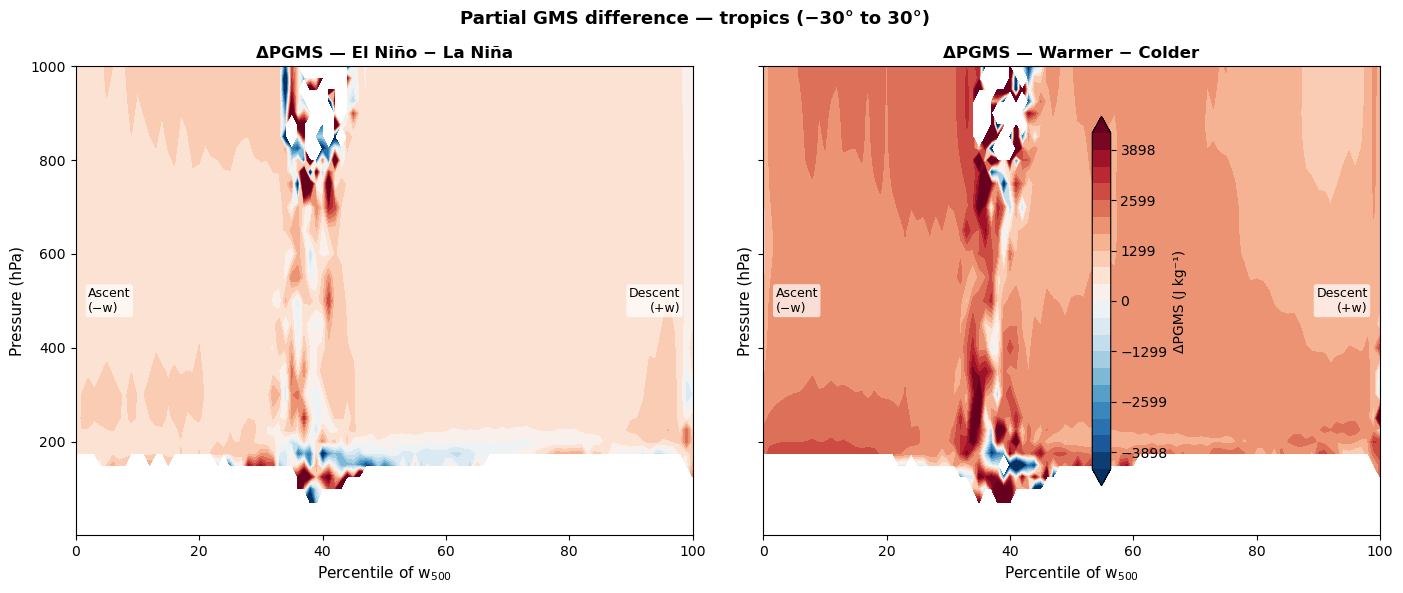

In [55]:
# ── plot: 2-panel difference (level × percentile) ─────────────────────────────
diff_enso     = pgms_elnino - pgms_lanina
diff_warmcold = pgms_new    - pgms_old

# ── clip outliers before setting colorscale ───────────────────────────────────
def robust_vmax(arr, pct=95):
    """Use a lower percentile to avoid colorscale being dominated by spikes."""
    return np.nanpercentile(np.abs(arr), pct)

vmax = max(robust_vmax(diff_enso.values), robust_vmax(diff_warmcold.values))
clevels = np.linspace(-vmax, vmax, 21)

# ── also clip the data itself so residual spikes don't distort contourf ───────
diff_enso.values[np.abs(diff_enso.values)     > vmax * 3] = np.nan
diff_warmcold.values[np.abs(diff_warmcold.values) > vmax * 3] = np.nan

vmax = np.nanpercentile(
    np.abs(np.stack([diff_enso.values, diff_warmcold.values])), 98
)
clevels = np.linspace(-vmax, vmax, 21)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

def plot_pgms_diff(da_diff, ax, title):
    pcts  = da_diff.percentile.values
    press = da_diff.level.values
    pcm = ax.contourf(pcts, press, da_diff.values,
                      levels=clevels, cmap="RdBu_r", extend="both")
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentile of w$_{500}$", fontsize=11)
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax_kw = dict(transform=ax.transAxes, fontsize=9, va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.5, "Ascent\n(−w)", ha="left",  **ax_kw)
    ax.text(0.98, 0.5, "Descent\n(+w)", ha="right", **ax_kw)
    return pcm

pcm1 = plot_pgms_diff(diff_enso,     axes[0], "ΔPGMS — El Niño − La Niña")
pcm2 = plot_pgms_diff(diff_warmcold, axes[1], "ΔPGMS — Warmer − Colder")

fig.colorbar(pcm1, ax=axes.tolist(), label="ΔPGMS (J kg⁻¹)", pad=0.02, shrink=0.8)

plt.suptitle("Partial GMS difference — tropics (−30° to 30°)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pgms_diff_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
# def compute_pgms(wh_sorted, ww_sorted, min_cum_mass_flux_Pa=500.0):
#     """
#     min_cum_mass_flux_Pa: minimum |∫w dp| in Pa*(Pa s-1) to trust the ratio.
#     500 Pa * 0.1 Pa/s = 50 Pa2/s is a reasonable floor — adjust if needed.
#     Points where |cum_ww| < threshold are set to NaN (near zero-crossing).
#     """
#     from scipy.integrate import cumulative_trapezoid

#     p_hPa = wh_sorted.level.values        # 1→1000 hPa, TOA first
#     p_Pa  = p_hPa * 100.0                 # Pa

#     n_time = wh_sorted.sizes["time"]
#     n_lev  = wh_sorted.sizes["level"]
#     n_pct  = wh_sorted.sizes["percentile"]

#     pgms_all = np.full((n_time, n_lev, n_pct), np.nan, dtype=np.float32)

#     for t in range(n_time):
#         wh_t = wh_sorted.isel(time=t).values   # (level, percentile)
#         ww_t = ww_sorted.isel(time=t).values   # (level, percentile)

#         cum_wh = cumulative_trapezoid(wh_t, p_Pa, axis=0, initial=0)  # (lev, pct)
#         cum_ww = cumulative_trapezoid(ww_t, p_Pa, axis=0, initial=0)  # (lev, pct)

#         # ── mask where denominator is too small ───────────────────────────────
#         # Use a fixed physical threshold rather than relative, to avoid
#         # masking too much in weak-circulation percentile bins
#         valid = np.abs(cum_ww) >= min_cum_mass_flux_Pa

#         pgms_t = np.full_like(wh_t, np.nan)
#         pgms_t[valid] = cum_wh[valid] / cum_ww[valid]

#         # ── also mask the TOA region (top 5 levels) — integral not meaningful ─
#         pgms_t[:10, :] = np.nan

#         pgms_all[t] = pgms_t

#     # warn if any bin is all-NaN
#     all_nan_bins = np.all(np.isnan(pgms_all), axis=0)
#     if all_nan_bins.any():
#         n = all_nan_bins.sum()
#         print(f"  Warning: {n} (level, percentile) bins are all-NaN "
#               f"— likely near zero-crossing. Consider adjusting min_cum_mass_flux_Pa.")

#     pgms_mean = np.nanmean(pgms_all, axis=0)

#     out = xr.DataArray(
#         pgms_mean,
#         dims=["level", "percentile"],
#         coords={
#             "level":      wh_sorted.level.values,
#             "percentile": wh_sorted.percentile.values,
#         },
#         name="PGMS",
#         attrs={
#             "long_name": "Partial Gross Moist Stability",
#             "units":     "J kg-1",
#             "formula":   "cumint(wh, TOA→p) / cumint(w, TOA→p)",
#         },
#     )
#     return out

def compute_pgms(wh_sorted, ww_sorted, threshold_frac=0.01):
    """
    threshold_frac: mask where |cum_ww| < threshold_frac * |cum_ww| at 500 hPa
                    i.e. relative to the mass flux accumulated down to 500 hPa.
                    This avoids masking the upper troposphere where the cumulative
                    integral is small simply because little pressure has been integrated.
    """
    from scipy.integrate import cumulative_trapezoid

    p_hPa = wh_sorted.level.values        # 1→1000 hPa, TOA first
    p_Pa  = p_hPa * 100.0

    # index of 500 hPa — used as reference level for threshold
    idx_500 = np.argmin(np.abs(p_hPa - 500.0))

    n_time = wh_sorted.sizes["time"]
    n_lev  = wh_sorted.sizes["level"]
    n_pct  = wh_sorted.sizes["percentile"]

    pgms_all = np.full((n_time, n_lev, n_pct), np.nan, dtype=np.float32)

    for t in range(n_time):
        wh_t = wh_sorted.isel(time=t).values   # (level, percentile)
        ww_t = ww_sorted.isel(time=t).values   # (level, percentile)

        cum_wh = cumulative_trapezoid(wh_t, p_Pa, axis=0, initial=0)
        cum_ww = cumulative_trapezoid(ww_t, p_Pa, axis=0, initial=0)

        # ── threshold: fraction of |cum_ww| at 500 hPa, per percentile column ─
        # shape: (percentile,) → broadcast to (level, percentile)
        ref = np.abs(cum_ww[idx_500, :])                      # (percentile,)
        threshold = threshold_frac * ref[np.newaxis, :]       # (1, percentile)
        threshold = np.maximum(threshold, 1.0)                # absolute floor

        valid = np.abs(cum_ww) >= threshold
        pgms_t = np.full_like(wh_t, np.nan)
        pgms_t[valid] = cum_wh[valid] / cum_ww[valid]

        # mask top 5 levels regardless — integral genuinely not meaningful there
        pgms_t[:9, :] = np.nan

        pgms_all[t] = pgms_t

    all_nan_bins = np.all(np.isnan(pgms_all), axis=0)
    if all_nan_bins.any():
        print(f"  Warning: {all_nan_bins.sum()} bins all-NaN "
              f"(threshold_frac={threshold_frac})")

    pgms_mean = np.nanmean(pgms_all, axis=0)

    return xr.DataArray(
        pgms_mean,
        dims=["level", "percentile"],
        coords={
            "level":      wh_sorted.level.values,
            "percentile": wh_sorted.percentile.values,
        },
        name="PGMS",
        attrs={
            "long_name":      "Partial Gross Moist Stability",
            "units":          "J kg-1",
            "formula":        "cumint(wh, TOA→p) / cumint(w, TOA→p)",
            "threshold_frac": str(threshold_frac),
        },
    )
# ── compute for all four composites ───────────────────────────────────────────
pgms_elnino = compute_pgms(wh_sorted_elnino_tropics, ww_sorted_elnino_tropics)
pgms_lanina = compute_pgms(wh_sorted_lanina_tropics, ww_sorted_lanina_tropics)
pgms_new    = compute_pgms(wh_sorted_new_tropics,    ww_sorted_new_tropics)
pgms_old    = compute_pgms(wh_sorted_old_tropics,    ww_sorted_old_tropics)

/tmp/ipykernel_2004/2106440080.py:111: RuntimeWarning: Mean of empty slice
  pgms_mean = np.nanmean(pgms_all, axis=0)


Zero-crossing at percentile ≈ 38


/tmp/ipykernel_2004/1706920949.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


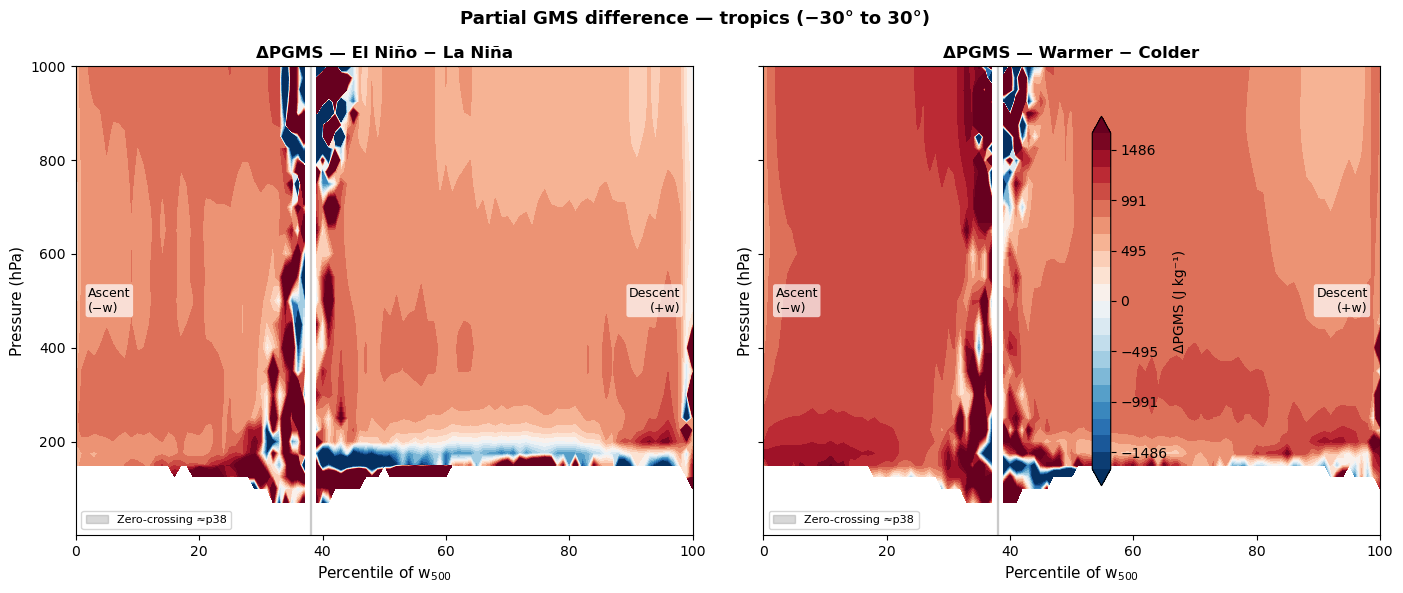

In [57]:
diff_enso     = pgms_elnino - pgms_lanina
diff_warmcold = pgms_new    - pgms_old

# ── find and mask the zero-crossing percentile band ──────────────────────────
# The zero-crossing is where mean w500 = 0, i.e. near p45-50
# Mask a band of ±5 percentiles around it in the plot
w500_mean = ww_sorted_elnino_tropics.sel(
    level=500, method="nearest").mean("time")             # (percentile,)
zero_cross_pct = float(
    ww_sorted_elnino_tropics.percentile.isel(
        percentile=int(np.argmin(np.abs(w500_mean.values)))
    )
)
print(f"Zero-crossing at percentile ≈ {zero_cross_pct:.0f}")

mask_band = 0.1   # ± percentile points to mask around zero-crossing
for diff in [diff_enso, diff_warmcold]:
    pcts = diff.percentile.values
    bad  = (pcts >= zero_cross_pct - mask_band) & (pcts <= zero_cross_pct + mask_band)
    diff.values[:, bad] = np.nan

# ── robust colorscale ignoring the masked region ─────────────────────────────
vmax = np.nanpercentile(
    np.abs(np.stack([diff_enso.values, diff_warmcold.values])), 95
)
clevels = np.linspace(-vmax, vmax, 21)
clevels1 = np.linspace(-vmax/2, vmax/2, 21)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

def plot_pgms_diff(da_diff, ax, title, zero_pct, clevels):
    pcts  = da_diff.percentile.values
    press = da_diff.level.values
    pcm = ax.contourf(pcts, press, da_diff.values,
                      levels=clevels, cmap="RdBu_r", extend="both")
    # shade the masked zero-crossing band
    ax.axvspan(zero_pct - mask_band, zero_pct + mask_band,
               color="grey", alpha=0.3, label=f"Zero-crossing ≈p{zero_pct:.0f}")
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentile of w$_{500}$", fontsize=11)
    ax.set_ylabel("Pressure (hPa)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax_kw = dict(transform=ax.transAxes, fontsize=9, va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.5, "Ascent\n(−w)", ha="left",  **ax_kw)
    ax.text(0.98, 0.5, "Descent\n(+w)", ha="right", **ax_kw)
    ax.legend(fontsize=8, loc="lower left")
    return pcm

pcm1 = plot_pgms_diff(diff_enso,     axes[0], "ΔPGMS — El Niño − La Niña",  zero_cross_pct, clevels1)
pcm2 = plot_pgms_diff(diff_warmcold, axes[1], "ΔPGMS — Warmer − Colder",     zero_cross_pct, clevels)

fig.colorbar(pcm1, ax=axes.tolist(), label="ΔPGMS (J kg⁻¹)", pad=0.02, shrink=0.8)

plt.suptitle("Partial GMS difference — tropics (−30° to 30°)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pgms_diff_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

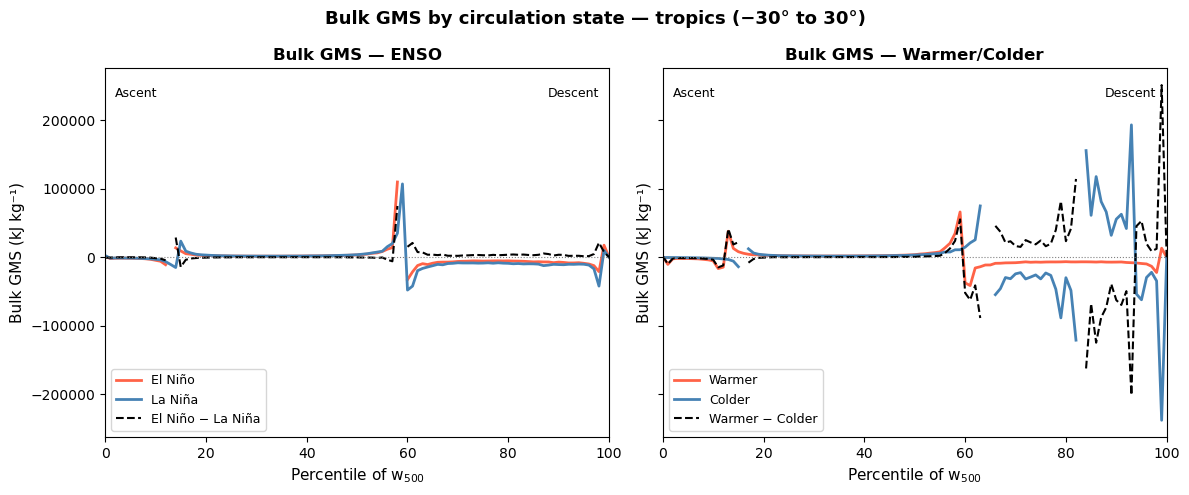

In [58]:
def compute_bulk_gms(mse_sorted, ww_sorted,
                     p_upper=slice(100, 400),    # upper troposphere
                     p_lower=slice(700, 1000)):  # lower troposphere
    """
    Bulk GMS for each percentile bin and time:
    Γ(pct) = [<wh>_upper - <wh>_lower] / [<w>_upper - <w>_lower]

    This avoids cumulative integration entirely — no zero-crossing problem.
    Returns DataArray (percentile,) after time-mean.
    """
    # time-mean first
    h = mse_sorted.mean("time")   # (level, percentile)
    w = ww_sorted.mean("time")    # (level, percentile)

    h_upper = h.sel(level=p_upper).mean("level")   # (percentile,)
    h_lower = h.sel(level=p_lower).mean("level")   # (percentile,)
    w_upper = w.sel(level=p_upper).mean("level")   # (percentile,)
    w_lower = w.sel(level=p_lower).mean("level")   # (percentile,)

    dh = h_upper - h_lower   # MSE contrast upper-lower
    dw = w_upper - w_lower   # mass flux contrast upper-lower

    with np.errstate(invalid="ignore", divide="ignore"):
        gms = np.where(np.abs(dw) > 1e-4, dh / dw, np.nan)

    out = xr.DataArray(
        gms,
        dims=["percentile"],
        coords={"percentile": mse_sorted.percentile.values},
        name="GMS",
        attrs={"long_name": "Bulk GMS", "units": "J kg-1"},
    )
    return out


# ── compute ───────────────────────────────────────────────────────────────────
gms_elnino = compute_bulk_gms(mse_sorted_elnino_tropics, ww_sorted_elnino_tropics)
gms_lanina = compute_bulk_gms(mse_sorted_lanina_tropics, ww_sorted_lanina_tropics)
gms_new    = compute_bulk_gms(mse_sorted_new_tropics,    ww_sorted_new_tropics)
gms_old    = compute_bulk_gms(mse_sorted_old_tropics,    ww_sorted_old_tropics)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

def plot_bulk_gms(ax, da1, da2, label1, label2, color1, color2, title):
    pcts = da1.percentile.values
    ax.plot(pcts, da1.values / 1e3, color=color1, lw=2, label=label1)
    ax.plot(pcts, da2.values / 1e3, color=color2, lw=2, label=label2)
    ax.plot(pcts, (da1 - da2).values / 1e3,
            color="k", lw=1.5, ls="--", label=f"{label1} − {label2}")
    ax.axhline(0, color="grey", lw=0.8, ls=":")
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentile of w$_{500}$", fontsize=11)
    ax.set_ylabel("Bulk GMS (kJ kg⁻¹)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax_kw = dict(transform=ax.transAxes, fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.95, "Ascent", ha="left",  va="top", **ax_kw)
    ax.text(0.98, 0.95, "Descent", ha="right", va="top", **ax_kw)
    ax.legend(fontsize=9)

plot_bulk_gms(axes[0], gms_elnino, gms_lanina,
              "El Niño", "La Niña", "tomato", "steelblue",
              "Bulk GMS — ENSO")
plot_bulk_gms(axes[1], gms_new, gms_old,
              "Warmer", "Colder", "tomato", "steelblue",
              "Bulk GMS — Warmer/Colder")

plt.suptitle("Bulk GMS by circulation state — tropics (−30° to 30°)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig("bulk_gms_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

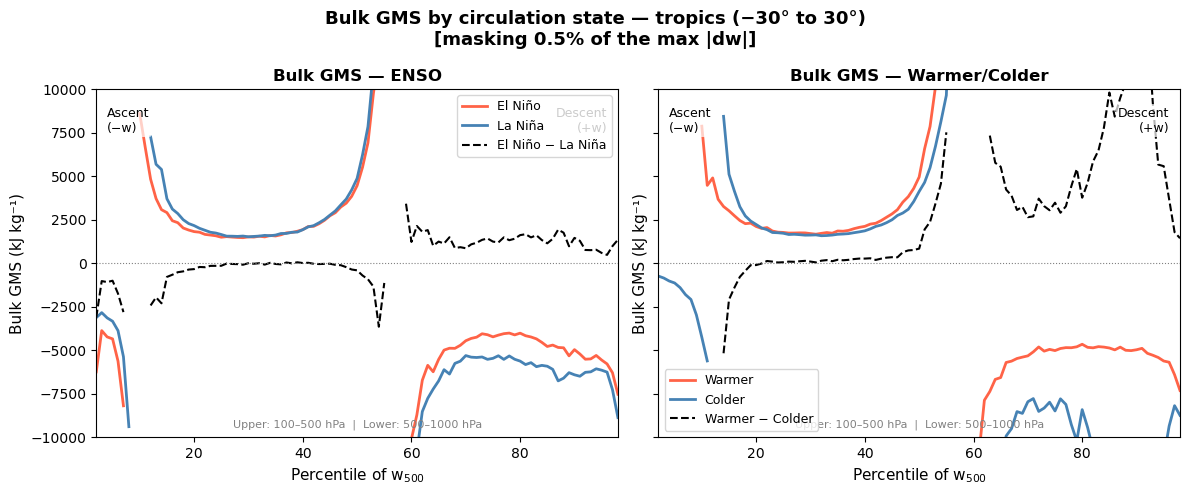

In [59]:
def compute_bulk_gms(mse_sorted, ww_sorted,
                     p_upper=(100, 400),
                     p_lower=(700, 1000),
                     threshold_pct = 0.005):
    """
    Bulk GMS for each percentile bin.
    Γ(pct) = [<h>_upper - <h>_lower] / [<w>_upper - <w>_lower]

    Uses MSE and w directly (not their product) — avoids needing wh_sorted.
    This is the simplified bulk form: MSE contrast / mass flux contrast.

    Parameters
    ----------
    p_upper : tuple (p_min, p_max) in hPa for upper troposphere
    p_lower : tuple (p_min, p_max) in hPa for lower troposphere
    """
    # time-mean
    h = mse_sorted.mean("time")   # (level, percentile)
    w = ww_sorted.mean("time")    # (level, percentile)

    # level selection using actual coordinate values
    h_upper = h.sel(level=slice(*p_upper)).mean("level")
    h_lower = h.sel(level=slice(*p_lower)).mean("level")
    w_upper = w.sel(level=slice(*p_upper)).mean("level")
    w_lower = w.sel(level=slice(*p_lower)).mean("level")

    dh = h_upper - h_lower
    dw = w_upper - w_lower

    # ── mask zero-crossings robustly ──────────────────────────────────────────
    # threshold: 5% of the max |dw| across all percentiles
    threshold = threshold_pct * float(np.nanmax(np.abs(dw.values)))
    threshold = max(threshold, 1e-4)   # absolute floor

    gms_vals = np.where(np.abs(dw.values) > threshold,
                        dh.values / dw.values,
                        np.nan)

    # ── also NaN the extreme percentile tails (sparse bins) ──────────────────
    pcts = mse_sorted.percentile.values
    gms_vals[(pcts < 2) | (pcts > 98)] = np.nan

    out = xr.DataArray(
        gms_vals,
        dims=["percentile"],
        coords={"percentile": pcts},
        name="GMS",
        attrs={
            "long_name": "Bulk GMS",
            "units":     "J kg-1",
            "p_upper":   f"{p_upper[0]}–{p_upper[1]} hPa",
            "p_lower":   f"{p_lower[0]}–{p_lower[1]} hPa",
        },
    )
    return out


# ── compute — you can now easily change pressure layers ───────────────────────
p_upper = (100, 500)      # upper troposphere
p_lower = (500, 1000)     # lower troposphere / surface layer
threshold_pct=0.005

gms_elnino = compute_bulk_gms(mse_sorted_elnino_tropics, ww_sorted_elnino_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)
gms_lanina = compute_bulk_gms(mse_sorted_lanina_tropics, ww_sorted_lanina_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)
gms_new    = compute_bulk_gms(mse_sorted_new_tropics,    ww_sorted_new_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)
gms_old    = compute_bulk_gms(mse_sorted_old_tropics,    ww_sorted_old_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)


# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

def plot_bulk_gms(ax, da1, da2, label1, label2, color1, color2, title, p_upper, p_lower):
    pcts = da1.percentile.values
    ax.plot(pcts, da1.values / 1e3, color=color1, lw=2,   label=label1)
    ax.plot(pcts, da2.values / 1e3, color=color2, lw=2,   label=label2)
    ax.plot(pcts, (da1 - da2).values / 1e3,
            color="k", lw=1.5, ls="--", label=f"{label1} − {label2}")
    ax.axhline(0, color="grey", lw=0.8, ls=":")
    ax.set_xlim(2, 98)
    ax.set_xlabel("Percentile of w$_{500}$", fontsize=11)
    ax.set_ylabel("Bulk GMS (kJ kg⁻¹)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    # pressure layer annotation
    ax.text(0.5, 0.02,
            f"Upper: {p_upper[0]}–{p_upper[1]} hPa  |  Lower: {p_lower[0]}–{p_lower[1]} hPa",
            transform=ax.transAxes, fontsize=8, ha="center", va="bottom",
            color="grey")
    ax_kw = dict(transform=ax.transAxes, fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
    ax.text(0.02, 0.95, "Ascent\n(−w)", ha="left",  va="top", **ax_kw)
    ax.text(0.98, 0.95, "Descent\n(+w)", ha="right", va="top", **ax_kw)
    ax.legend(fontsize=9)
    ax.set_ylim(-10000,10000)

plot_bulk_gms(axes[0], gms_elnino, gms_lanina,
              "El Niño", "La Niña", "tomato", "steelblue",
              "Bulk GMS — ENSO", p_upper, p_lower)
plot_bulk_gms(axes[1], gms_new, gms_old,
              "Warmer", "Colder", "tomato", "steelblue",
              "Bulk GMS — Warmer/Colder", p_upper, p_lower)

plt.suptitle(
    f"Bulk GMS by circulation state — tropics (−30° to 30°)\n"
    f"[masking {threshold_pct*100:.1f}% of the max |dw|]",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
# plt.savefig("bulk_gms_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

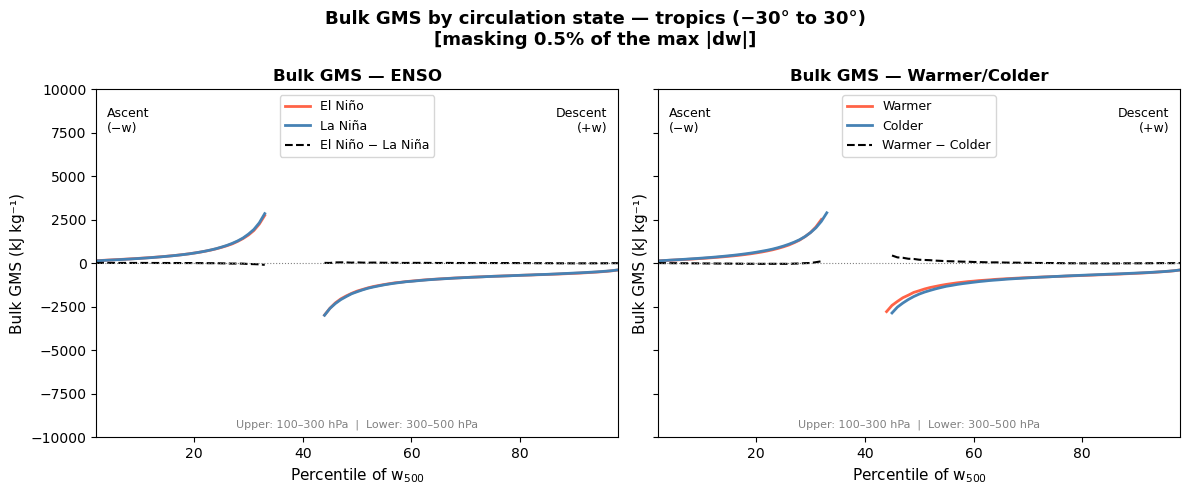

In [60]:
# ── compute — you can now easily change pressure layers ───────────────────────
p_upper = (100, 300)      # upper troposphere
p_lower = (300, 500)     # lower troposphere / surface layer
# threshold_pct=0.01

gms_elnino = compute_bulk_gms(mse_sorted_elnino_tropics, ww_sorted_elnino_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)
gms_lanina = compute_bulk_gms(mse_sorted_lanina_tropics, ww_sorted_lanina_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)
gms_new    = compute_bulk_gms(mse_sorted_new_tropics,    ww_sorted_new_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)
gms_old    = compute_bulk_gms(mse_sorted_old_tropics,    ww_sorted_old_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)


# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

plot_bulk_gms(axes[0], gms_elnino, gms_lanina,
              "El Niño", "La Niña", "tomato", "steelblue",
              "Bulk GMS — ENSO", p_upper, p_lower)
plot_bulk_gms(axes[1], gms_new, gms_old,
              "Warmer", "Colder", "tomato", "steelblue",
              "Bulk GMS — Warmer/Colder", p_upper, p_lower)

plt.suptitle(
    f"Bulk GMS by circulation state — tropics (−30° to 30°)\n"
    f"[masking {threshold_pct*100:.1f}% of the max |dw|]",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
# plt.savefig("bulk_gms_tropics.png", dpi=150, bbox_inches="tight")
plt.show()

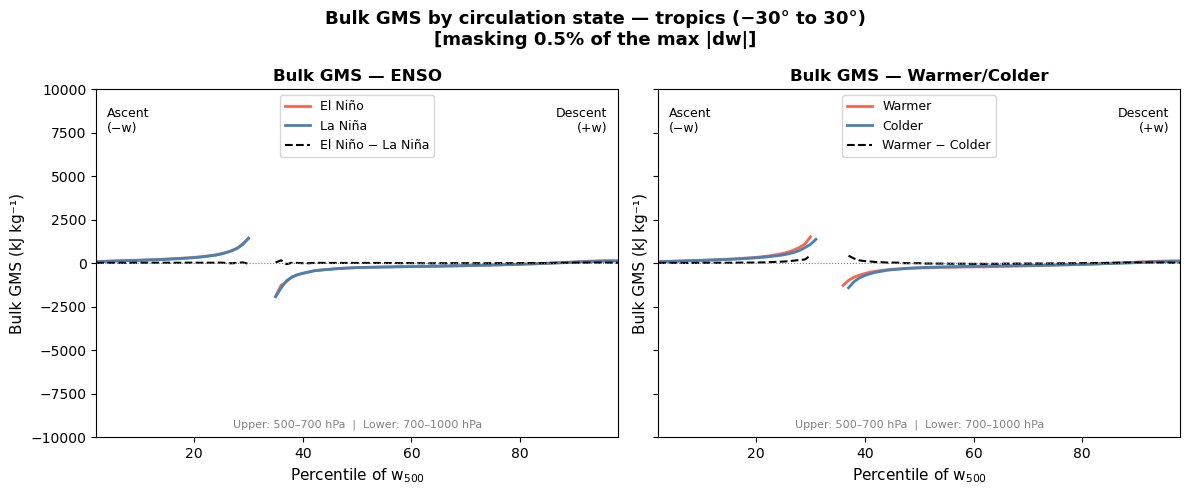

In [61]:
# ── compute — you can now easily change pressure layers ───────────────────────
p_upper = (500, 700)      # upper troposphere
p_lower = (700, 1000)     # lower troposphere / surface layer
# threshold_pct=0.01

gms_elnino = compute_bulk_gms(mse_sorted_elnino_tropics, ww_sorted_elnino_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)
gms_lanina = compute_bulk_gms(mse_sorted_lanina_tropics, ww_sorted_lanina_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)
gms_new    = compute_bulk_gms(mse_sorted_new_tropics,    ww_sorted_new_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)
gms_old    = compute_bulk_gms(mse_sorted_old_tropics,    ww_sorted_old_tropics,
                               p_upper=p_upper, p_lower=p_lower, threshold_pct = threshold_pct)


# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

plot_bulk_gms(axes[0], gms_elnino, gms_lanina,
              "El Niño", "La Niña", "tomato", "steelblue",
              "Bulk GMS — ENSO", p_upper, p_lower)
plot_bulk_gms(axes[1], gms_new, gms_old,
              "Warmer", "Colder", "tomato", "steelblue",
              "Bulk GMS — Warmer/Colder", p_upper, p_lower)

plt.suptitle(
    f"Bulk GMS by circulation state — tropics (−30° to 30°)\n"
    f"[masking {threshold_pct*100:.1f}% of the max |dw|]",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
# plt.savefig("bulk_gms_tropics.png", dpi=150, bbox_inches="tight")
plt.show()